In [ ]:
options(future.globals.maxSize = 100000000 * 1024^2)

# set random seed for reproducibility
set.seed(12345)

# ========================= Libraries ===================================


## We load the required packages
library(dplyr)
library(Seurat)
library(readr)
library(readr)
# single-cell analysis package
# plotting and data science packages
# library(tidyverse)
library(cowplot)
library(patchwork)
library(ggplot2)
# co-expression network analysis packages:
library(igraph)
library(harmony)
library(dittoSeq)
library(RColorBrewer)

library(org.Hs.eg.db)
require(tidyverse)
library(clusterProfiler)
library(WGCNA)
library(hdWGCNA)
library(scCustomize)
library(harmony)


library(SCopeLoomR)
library(dreamlet)
library(SingleCellExperiment)
library(scater)
# library(UCell)
# library(Nebulosa)

library(SingleCellExperiment)
library(scuttle)
library(Seurat)
library(doParallel)
'%notin%' <- Negate('%in%')

# plotting
library(ggplot2)
library(dplyr)
library(RColorBrewer)
library(cowplot)
library(ggtree)
library(aplot)
library(circlize)
library(ComplexHeatmap)

# meta
library(tidyr)
library(muscat)
library(broom)
library(tidyverse)
library(metafor) 

input_rds <- args[1]
group_by <- args[2]
only_microglia <- as.logical(args[3])
n_of_aggregated <- as.numeric(args[4]) # 25
n_of_aggregated_text <- args[4]
threads <- as.numeric(args[5])
output_pdf <- args[6]

workdir <- "7.WGCNA/"
source('utils.R')
dir.create(workdir)
registerDoParallel(cores=threads)
colors <- brewer.pal(n = 9, name = 'Set3')
colors[2] <- colors[8]
colors[8] <- "azure3"
colors_rb <- rev(brewer.pal(n = 6, name = 'RdGy'))


In [ ]:
library(anndata)

In [ ]:
library(CellChat)

In [4]:
Immune.combined <- readCRDS('2024_03_28_Immune_Combined_Metacells.rds.ztsd')

In [ ]:
options(repr.plot.width=6, repr.plot.height=5)
DimPlot(Immune.combined,group.by = 'Clusters')

In [6]:
Idents(Immune.combined) <- 'Clusters'
Immune.combined$samples <- Immune.combined$orig.ident

In [7]:
cellChat <- createCellChat(object = Immune.combined, group.by = "Clusters", assay = "RNAv3")


[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 


Warning message in createCellChat(object = Immune.combined, group.by = "Clusters", :
"The 'meta$samples' is not a factor. We now force it as a factor!"


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B Cells, MONO, MTC_123, MTC_456, MTC_Prolif, NEUT, T Cells 


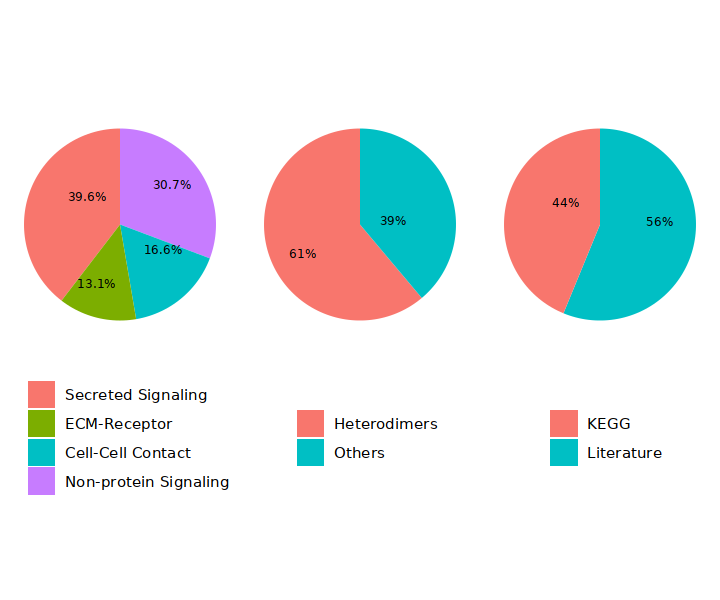

In [8]:
CellChatDB <- CellChatDB.human # use CellChatDB.mouse if running on mouse data
showDatabaseCategory(CellChatDB)

[1] "Create a CellChat object from a Seurat object"
The `data` slot in the default assay is used. The default assay is RNAv3 
The `meta.data` slot in the Seurat object is used as cell meta information 


Warning message in createCellChat(object = Immune.combined, group.by = "Clusters"):
"The 'meta$samples' is not a factor. We now force it as a factor!"


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B Cells, MONO, MTC_123, MTC_456, MTC_Prolif, NEUT, T Cells 


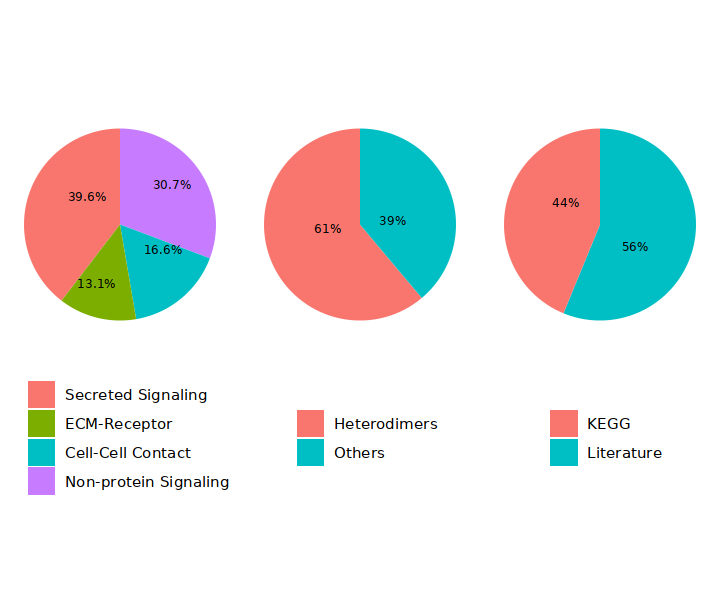

In [9]:
# transform seurat obj to cellchat obj#
cellchat <- createCellChat(object = Immune.combined, # this is my seurat obj
                           group.by = "Clusters")

# set the database#
CellChatDB <- CellChatDB.human # use CellChatDB.mouse if running on mouse data
showDatabaseCategory(CellChatDB)

# subset the expression data of signaling genes for saving computation cost
cellchat@DB <- CellChatDB
cellchat <- subsetData(cellchat) # This step is necessary even if using the whole database
cellchat <- identifyOverExpressedGenes(cellchat)

In [10]:
cellchat <- identifyOverExpressedInteractions(cellchat)


The number of highly variable ligand-receptor pairs used for signaling inference is 1223 


# Compute the communication probability and infer cellular communication network

In [11]:
cellchat <- computeCommunProb(cellchat, type = "triMean")


triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2024-04-22 05:44:21.891023]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2024-04-22 05:57:36.001068]"


In [12]:
cellchat <- filterCommunication(cellchat, min.cells = 10)


In [13]:
cellchat <- computeCommunProbPathway(cellchat)


# Calculate the aggregated cell-cell communication network


In [14]:
cellchat <- aggregateNet(cellchat)
# execution.time = Sys.time() - ptm
# print(as.numeric(execution.time, units = "secs"))

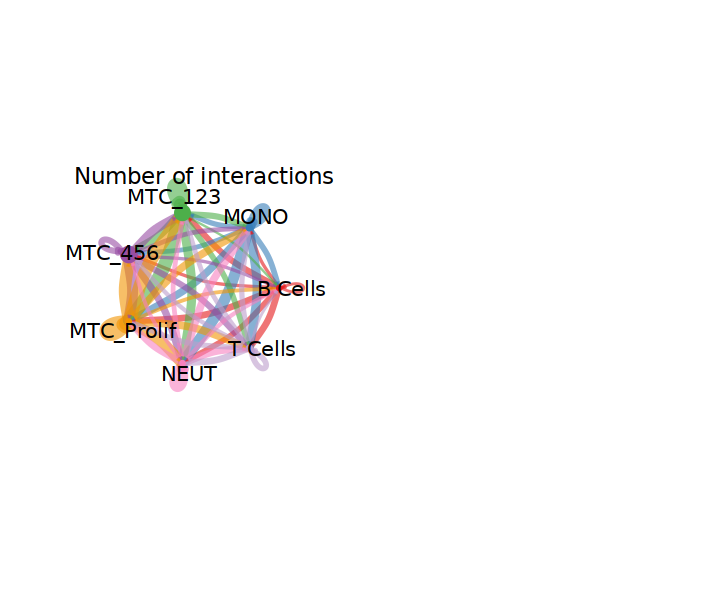

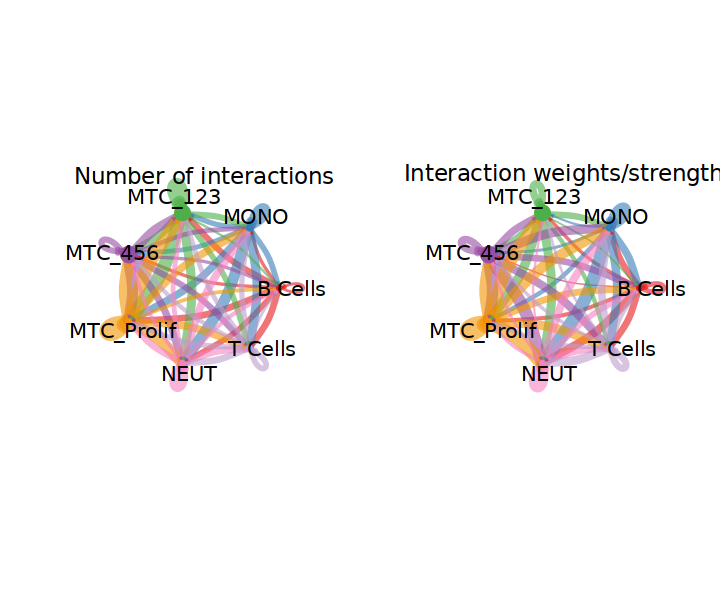

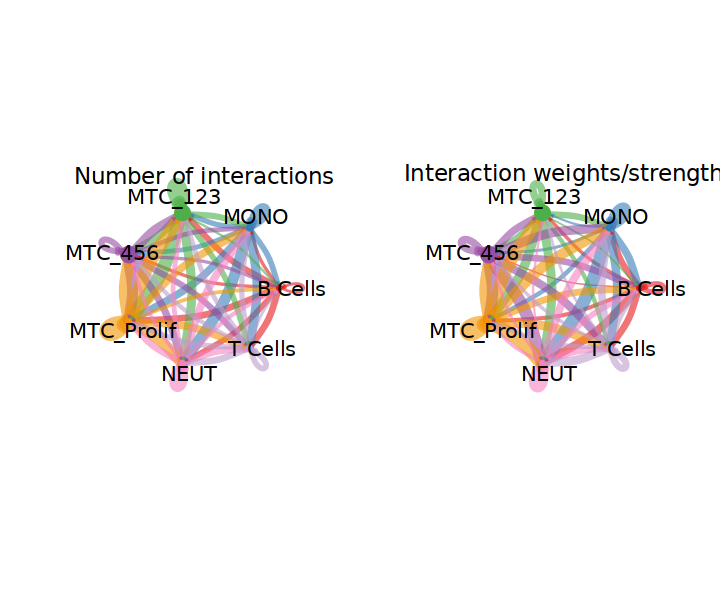

In [15]:
# ptm = Sys.time()
groupSize <- as.numeric(table(cellchat@idents))
par(mfrow = c(1,2), xpd=TRUE)
netVisual_circle(cellchat@net$count, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Number of interactions")
netVisual_circle(cellchat@net$weight, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Interaction weights/strength")

In [16]:
colnames(cellchat@net$weight)

[1] "B Cells"    "MONO"       "MTC_123"    "MTC_456"    "MTC_Prolif"
[6] "NEUT"       "T Cells"

In [17]:
node_colors = c(
    '#F4B462',
    '#80B1D3',
    '#999999',
    '#A32A31',
    '#EE8172',
    '#DBDB98',
    '#B1DD69',
    '#8CD3C5'
)

names(node_colors)<-colnames(cellchat@net$weight)

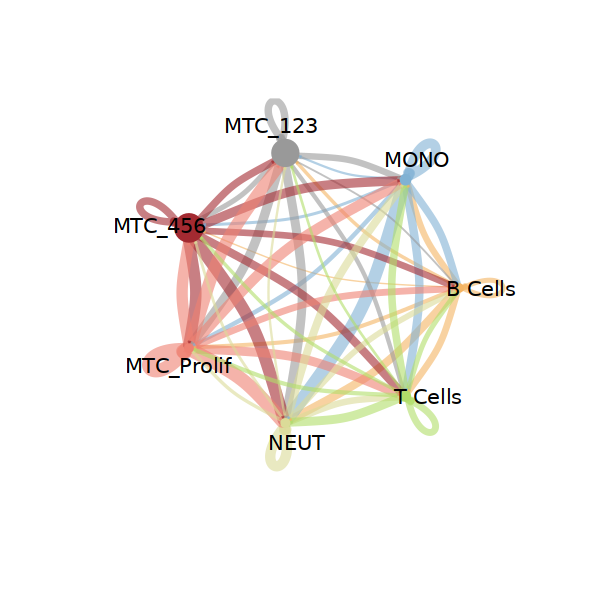

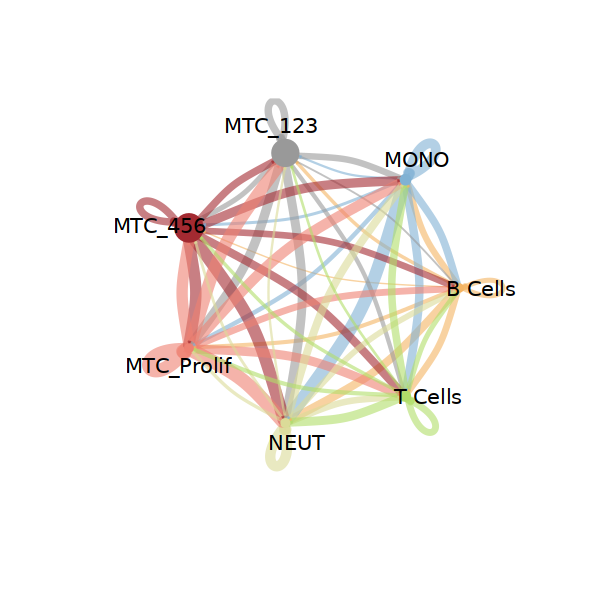

In [18]:
options(repr.plot.width=5, repr.plot.height=5)
netVisual_circle(cellchat@net$weight, 
                 vertex.weight = groupSize,
                 color.use=node_colors,
                 weight.scale = T, 
                 label.edge= F, 
                 title.name = "Interaction weights/strength")

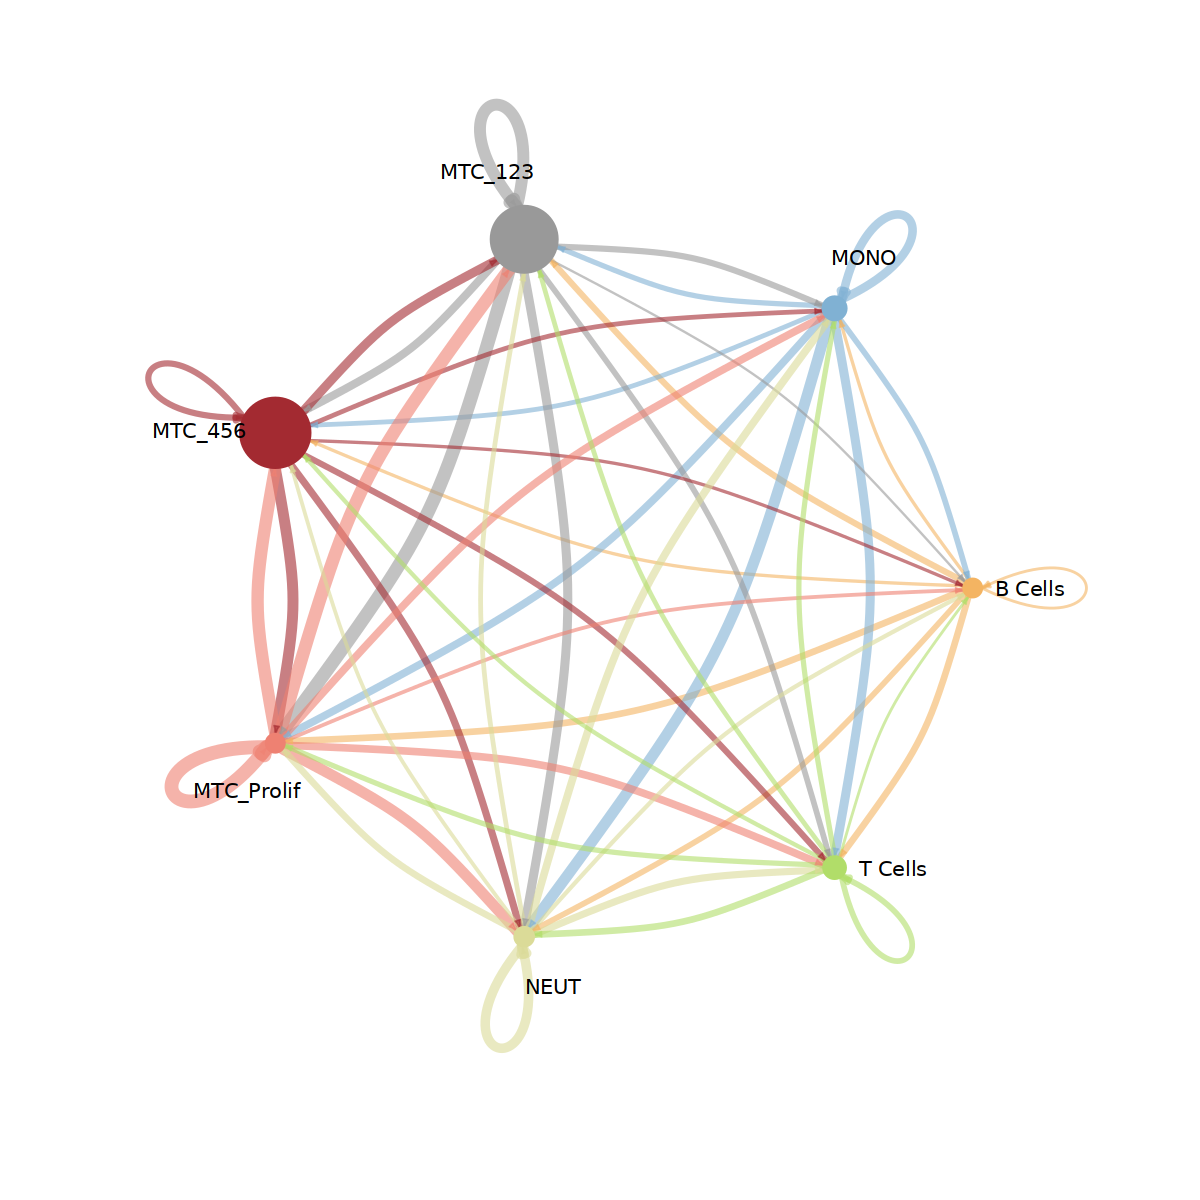

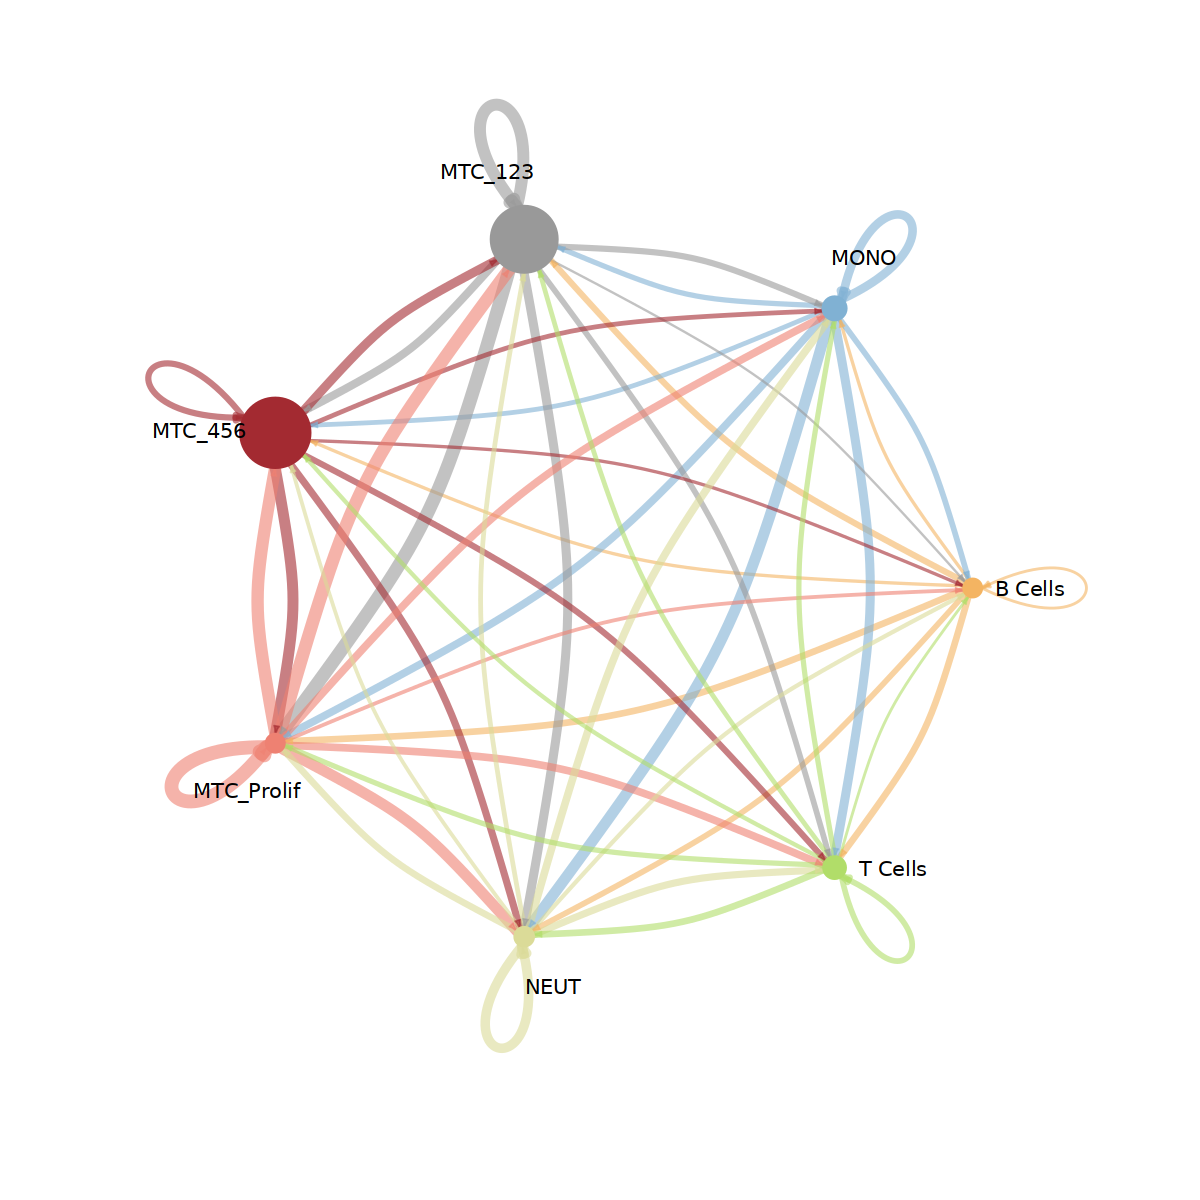

In [19]:
options(repr.plot.width=10, repr.plot.height=10)
netVisual_circle(cellchat@net$count, 
                 vertex.weight = groupSize, 
                 weight.scale = T, 
                 color.use=node_colors,
                 label.edge= F, 
                 title.name = "Number of interactions")


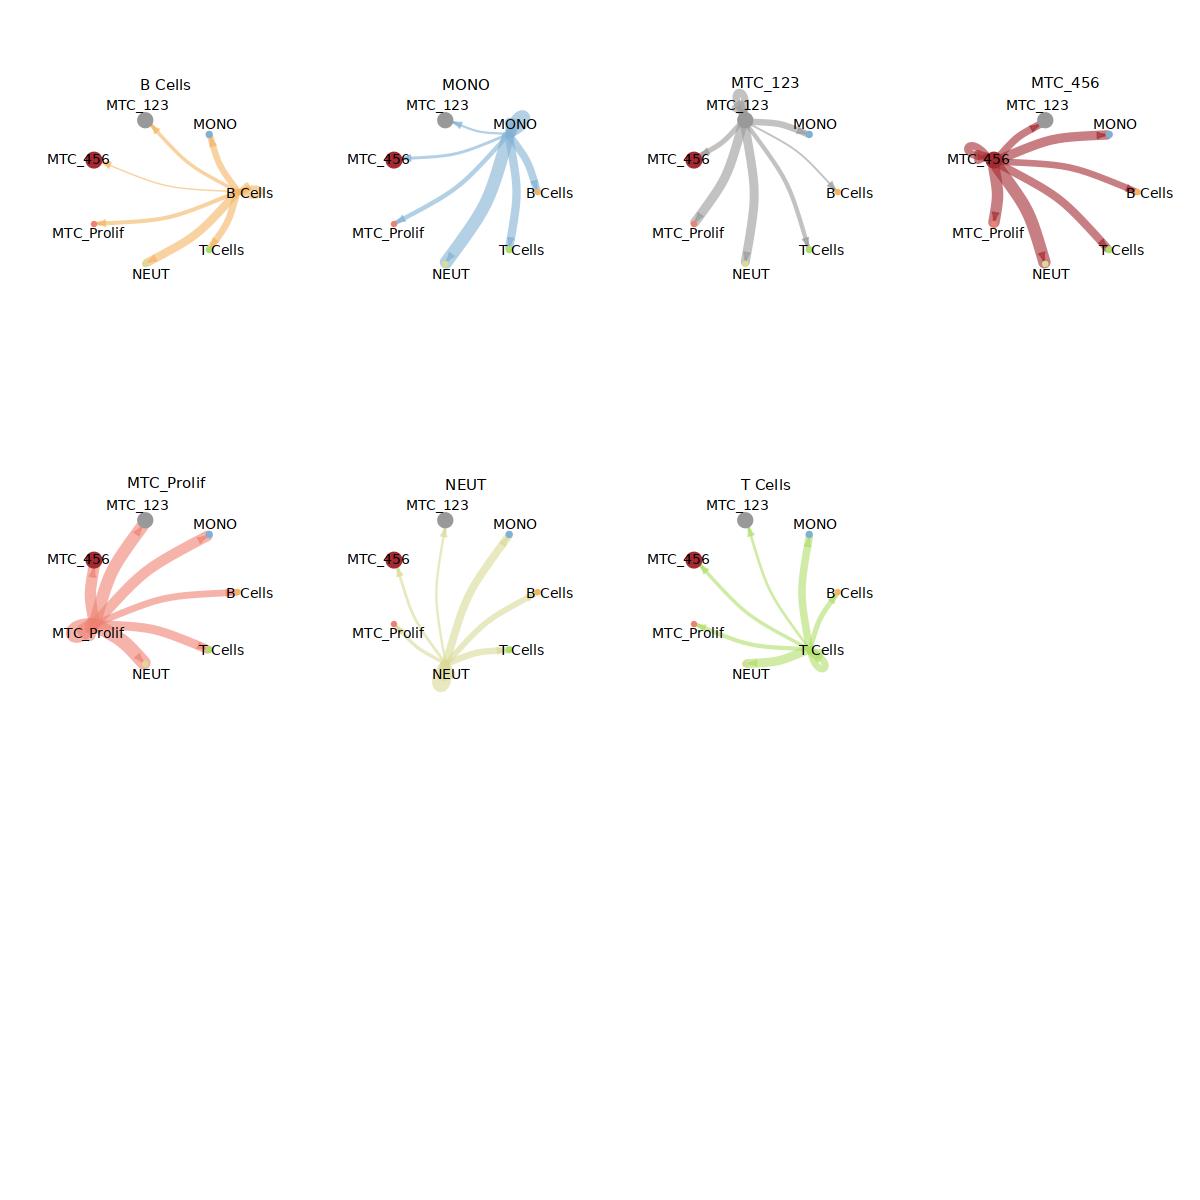

In [27]:
options(repr.plot.width=10, repr.plot.height=10)
mat <- cellchat@net$weight
par(mfrow = c(3,4), xpd=TRUE)
for (i in 1:nrow(mat)) {
  mat2 <- matrix(0, nrow = nrow(mat), ncol = ncol(mat), dimnames = dimnames(mat))
  mat2[i, ] <- mat[i, ]
  netVisual_circle(mat2, vertex.weight = groupSize,color.use=node_colors,, weight.scale = T, edge.weight.max = max(mat), title.name = rownames(mat)[i])
}

In [21]:
cellchat@netP$pathways

[1] "MIF"           "SPP1"          "MHC-II"        "GALECTIN"     
 [5] "ApoE"          "COMPLEMENT"    "CD99"          "CypA"         
 [9] "ANNEXIN"       "CCL"           "MHC-I"         "CD45"         
[13] "APP"           "CLEC"          "Prostaglandin" "TNF"          
[17] "LAIR1"         "ADGRE"         "RESISTIN"      "CD39"         
[21] "GRN"           "THBS"          "TGFb"          "GAS"          
[25] "FN1"           "IFN-II"        "Cholesterol"   "SELPLG"       
[29] "IL16"          "IL10"          "PECAM1"        "BAFF"         
[33] "LXA4"          "MPZ"           "SEMA4"         "TWEAK"

In [22]:
getwd()

[1] "/sc/arion/projects/CommonMind/kyriad02/ICH_Stroke"

In [23]:
pathways.show.all <- cellchat@netP$pathways
pathways.show.all

[1] "MIF"           "SPP1"          "MHC-II"        "GALECTIN"     
 [5] "ApoE"          "COMPLEMENT"    "CD99"          "CypA"         
 [9] "ANNEXIN"       "CCL"           "MHC-I"         "CD45"         
[13] "APP"           "CLEC"          "Prostaglandin" "TNF"          
[17] "LAIR1"         "ADGRE"         "RESISTIN"      "CD39"         
[21] "GRN"           "THBS"          "TGFb"          "GAS"          
[25] "FN1"           "IFN-II"        "Cholesterol"   "SELPLG"       
[29] "IL16"          "IL10"          "PECAM1"        "BAFF"         
[33] "LXA4"          "MPZ"           "SEMA4"         "TWEAK"

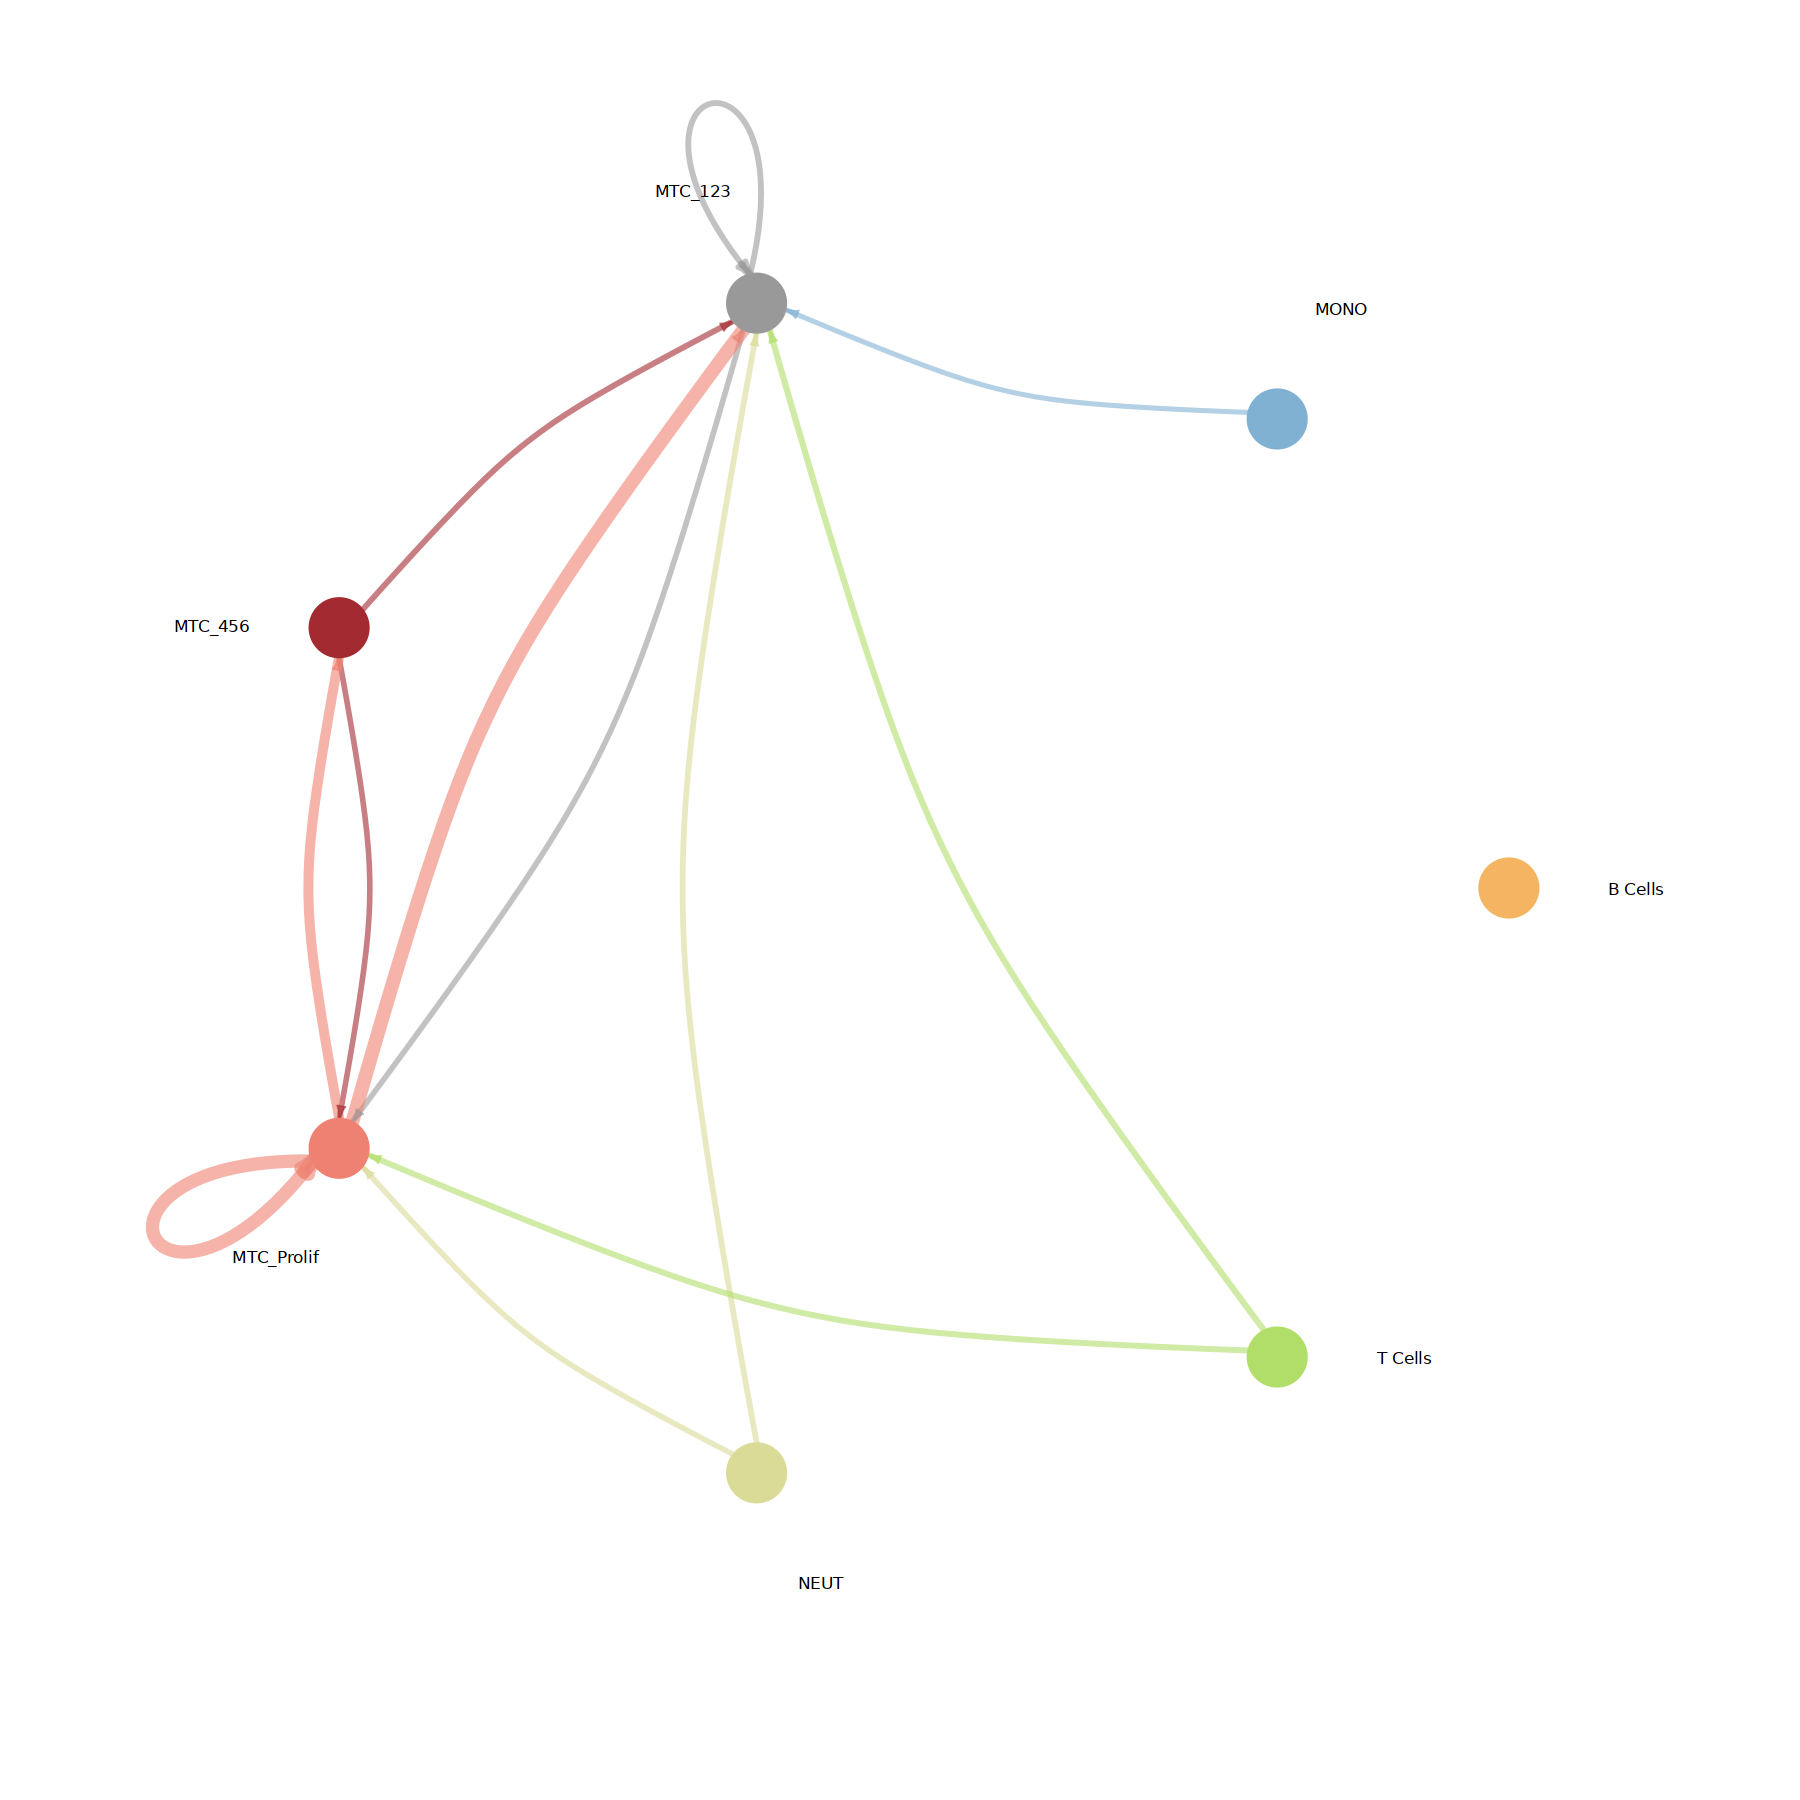

In [38]:
gg <- netVisual_aggregate(cellchat, signaling = "TGFb", layout = "circle",color.use=node_colors,)

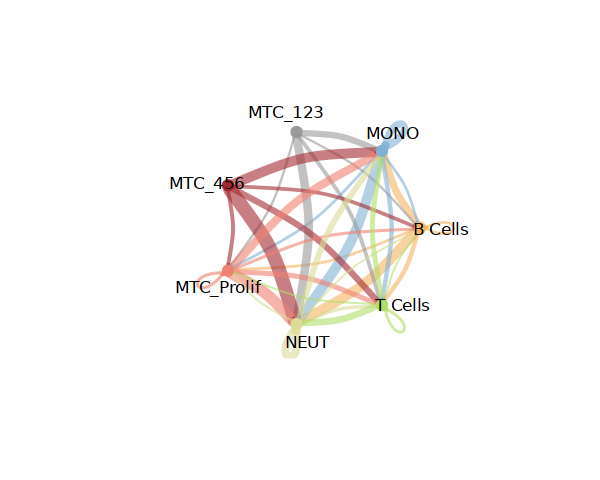

In [41]:
gg <- netVisual_aggregate(cellchat, signaling = "SPP1", layout = "circle",color.use=node_colors,)

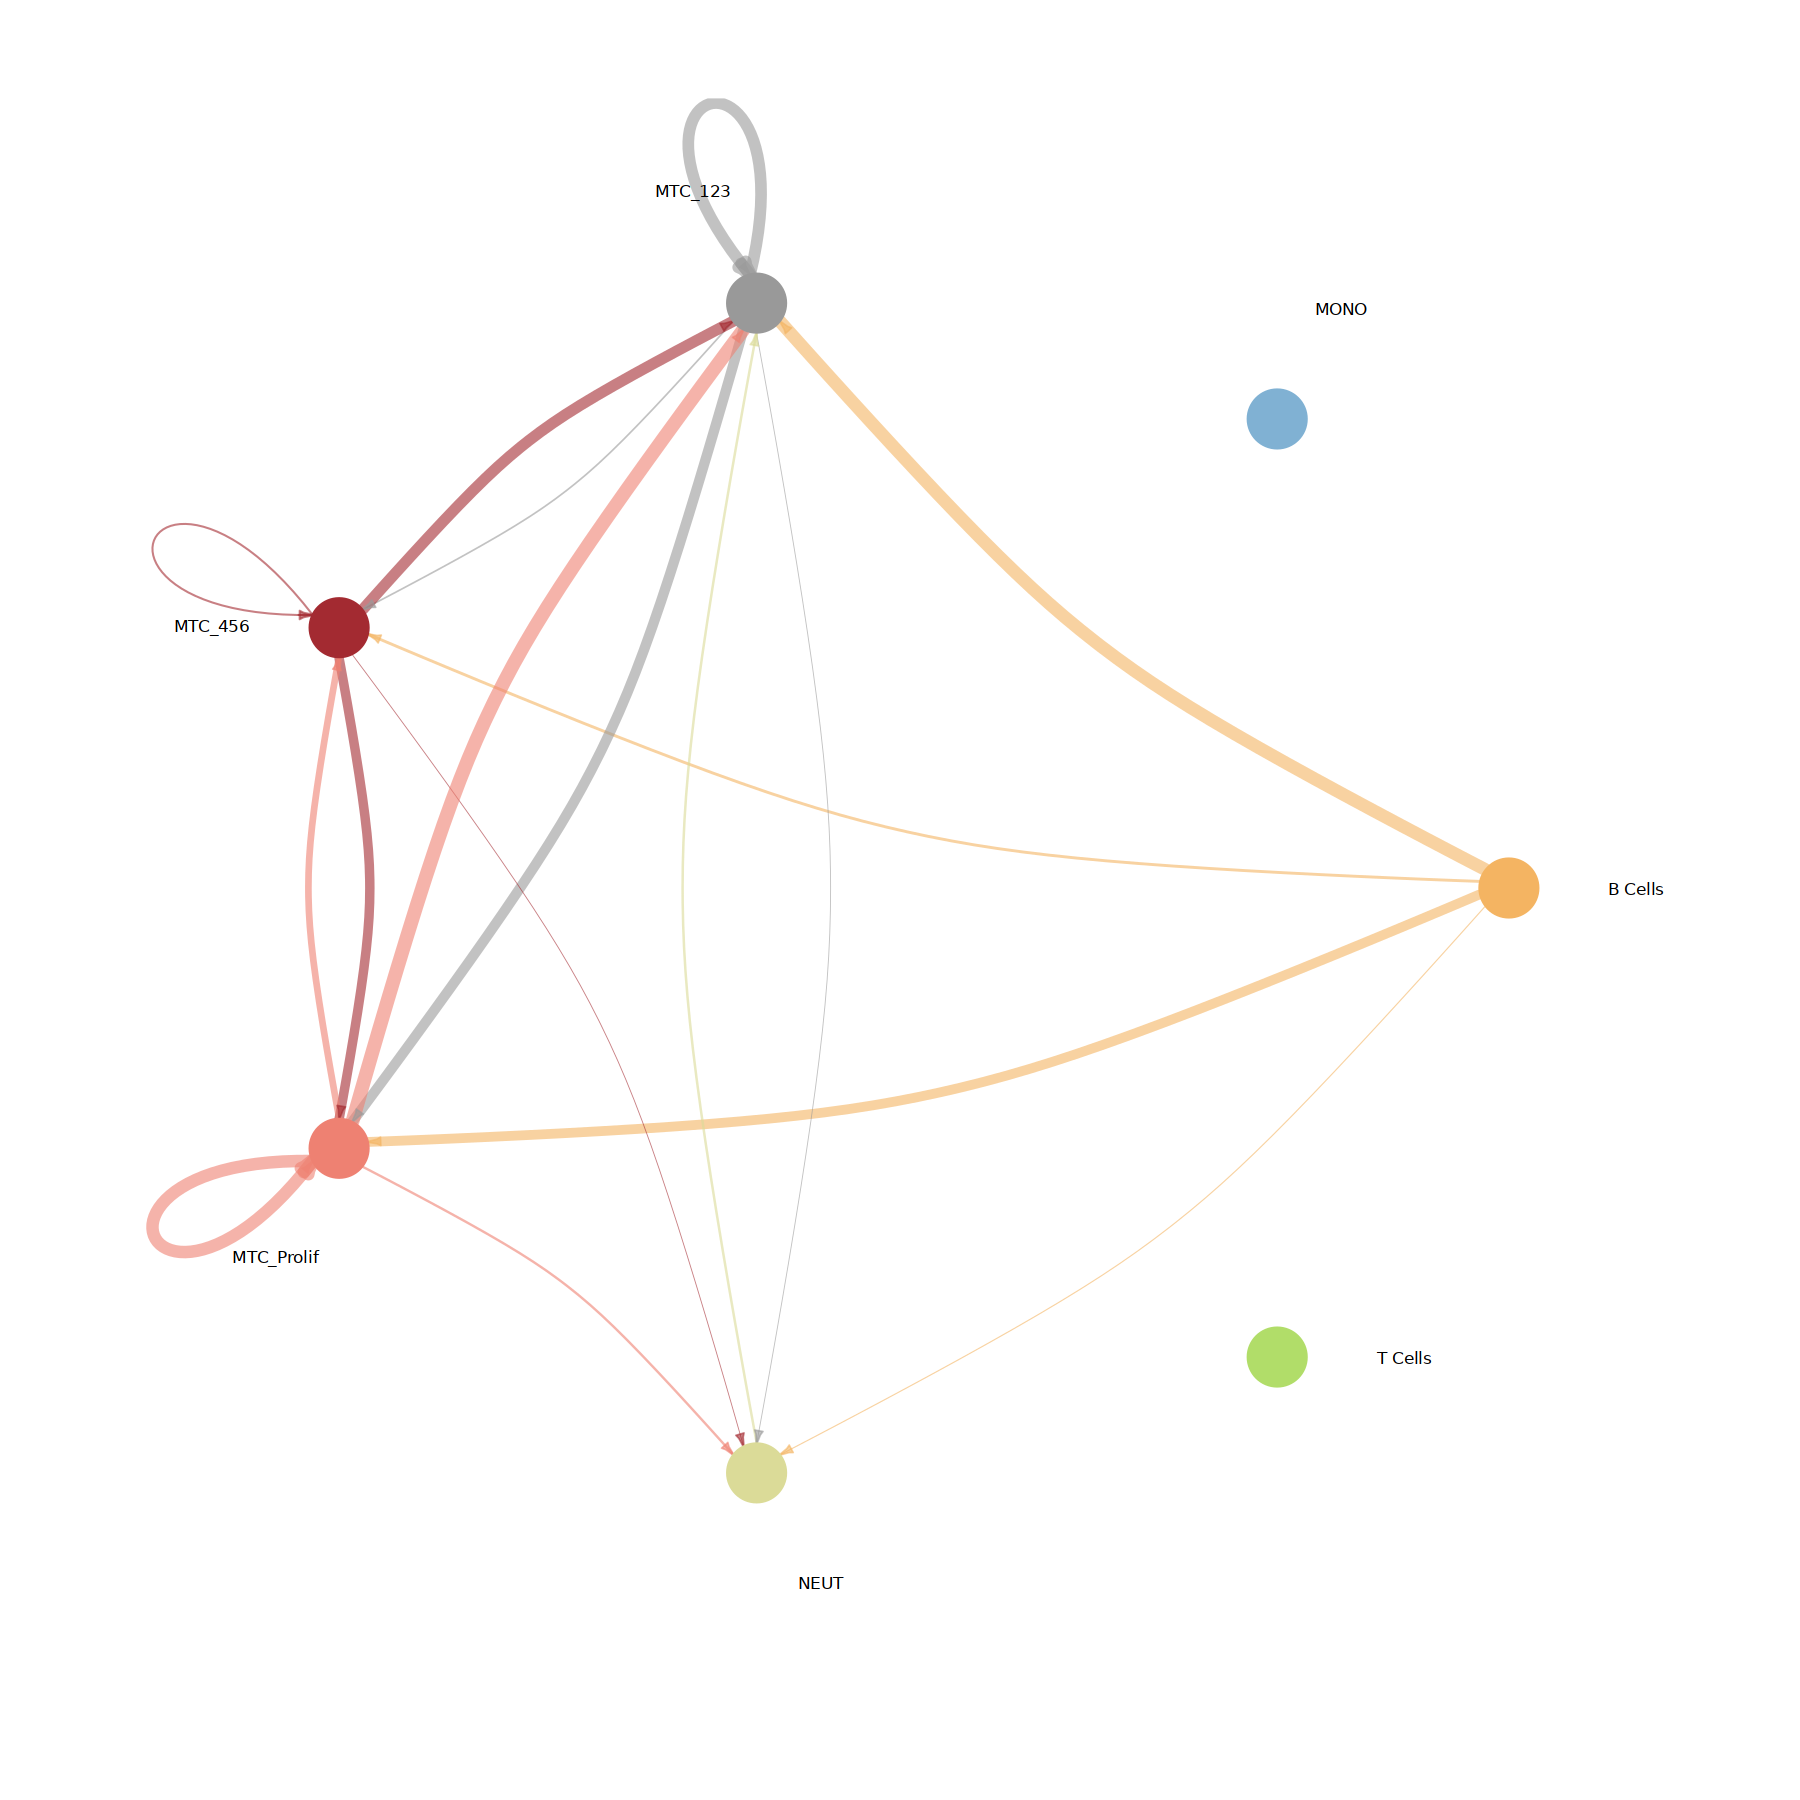

In [35]:
gg <- netVisual_aggregate(cellchat, signaling = "MHC-II", layout = "circle",color.use=node_colors,)

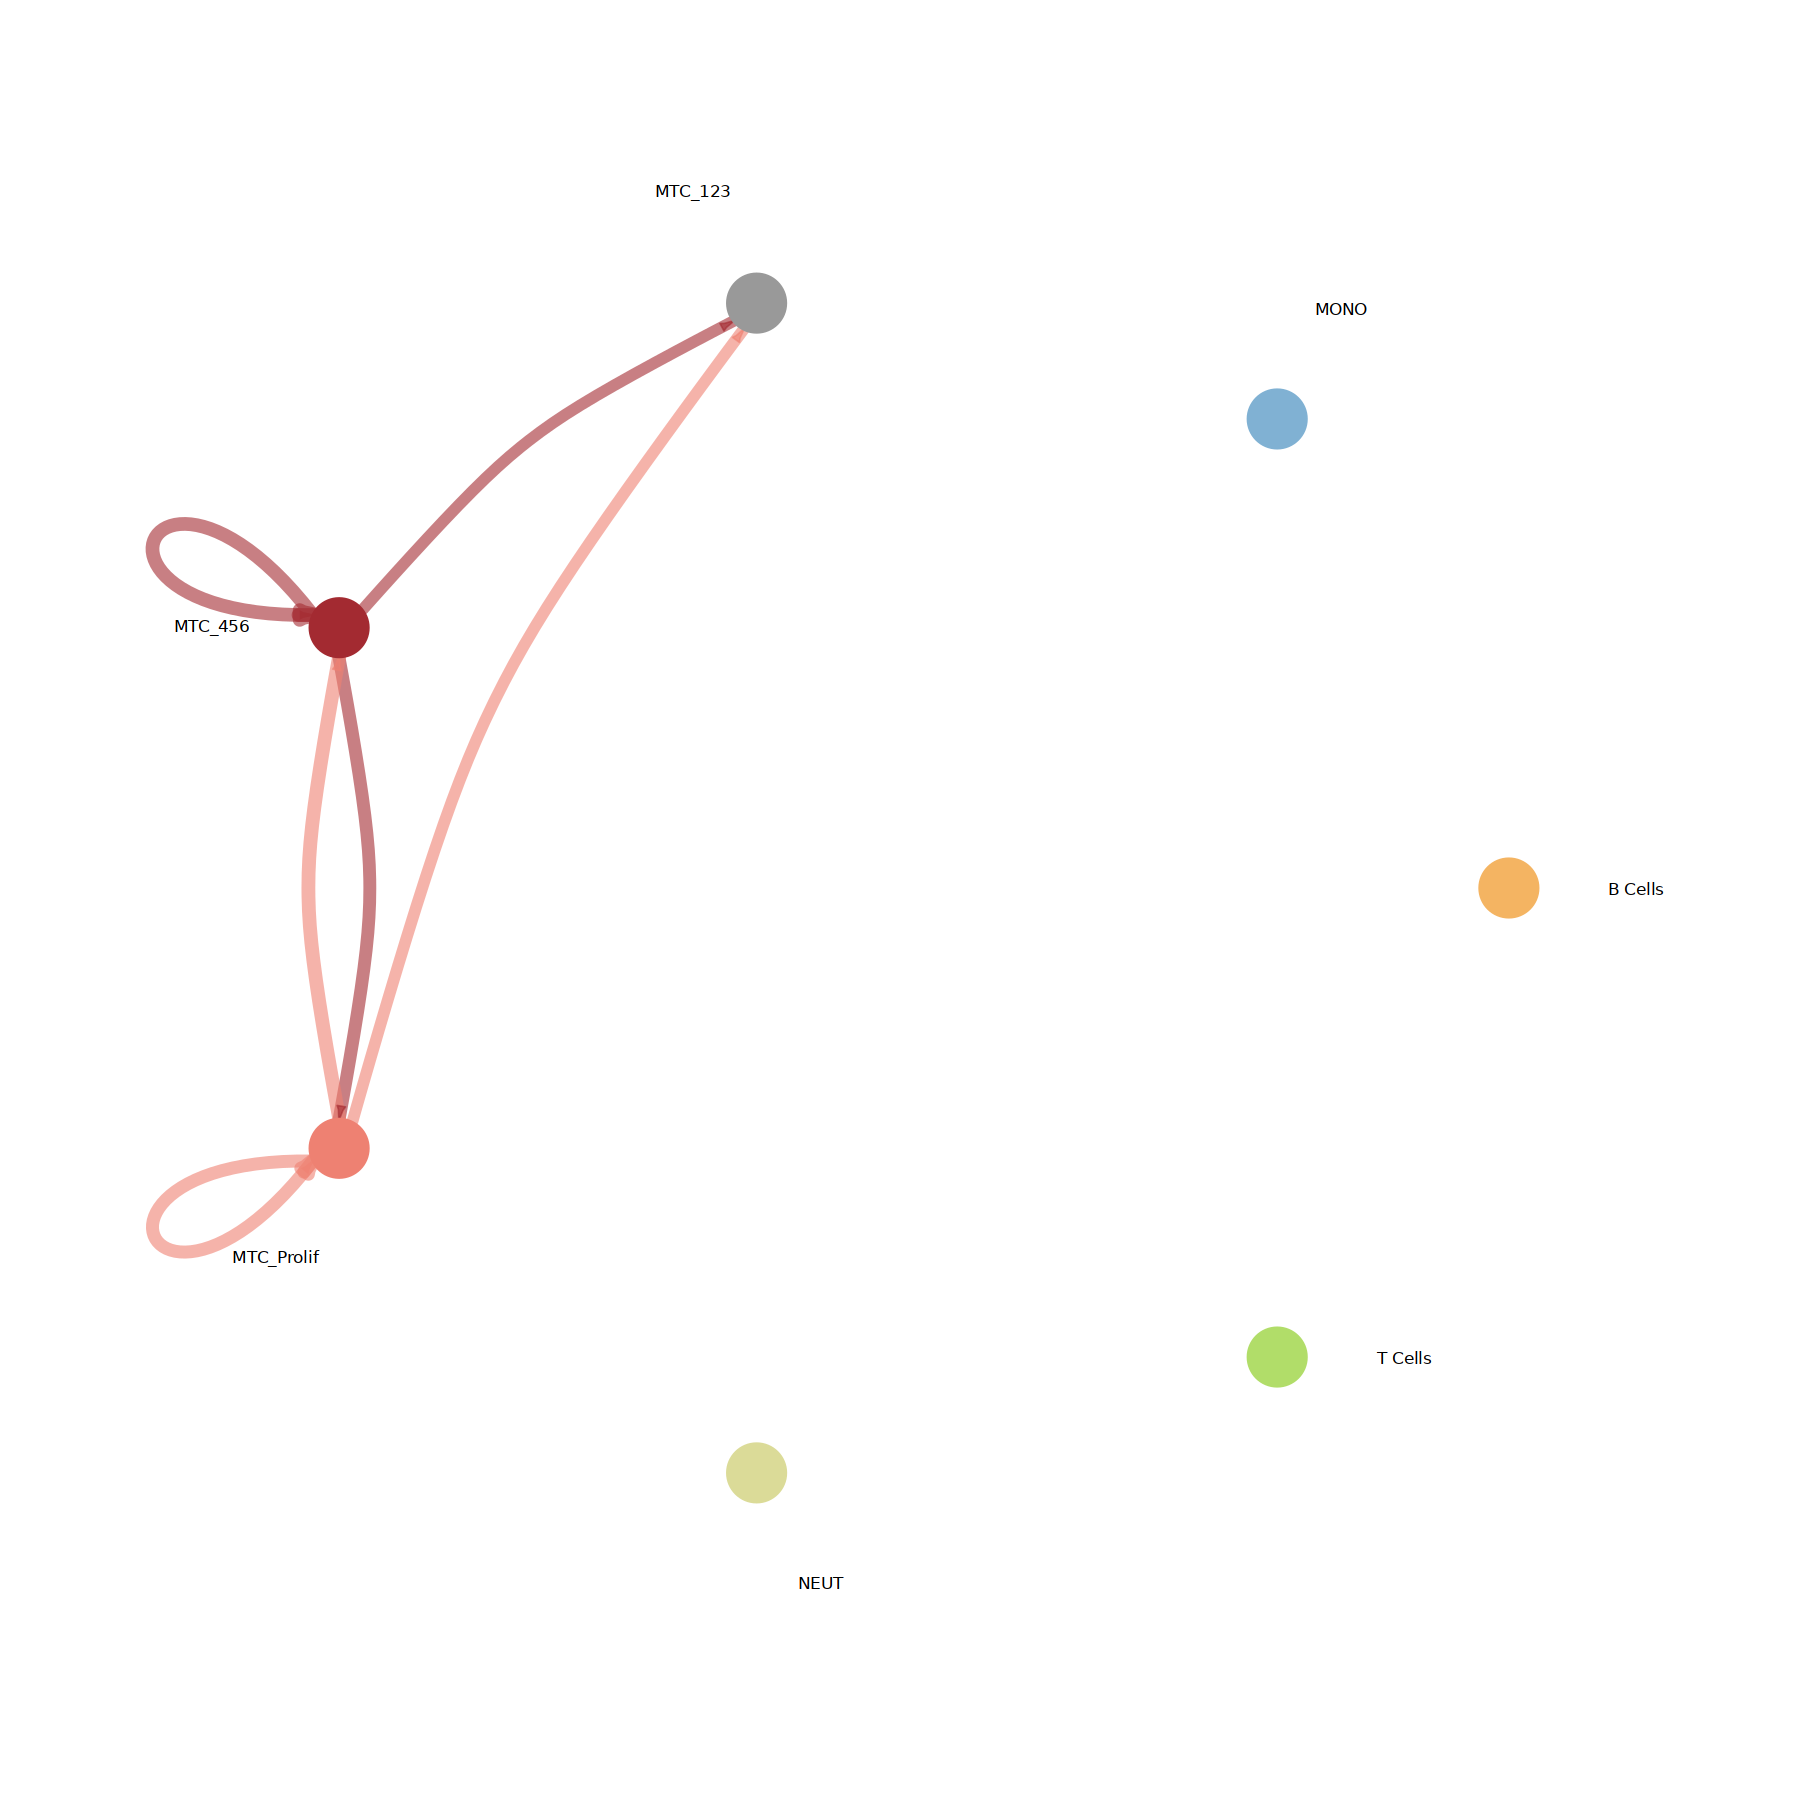

In [34]:
gg <- netVisual_aggregate(cellchat, signaling = "ApoE", layout = "circle",color.use=node_colors,)

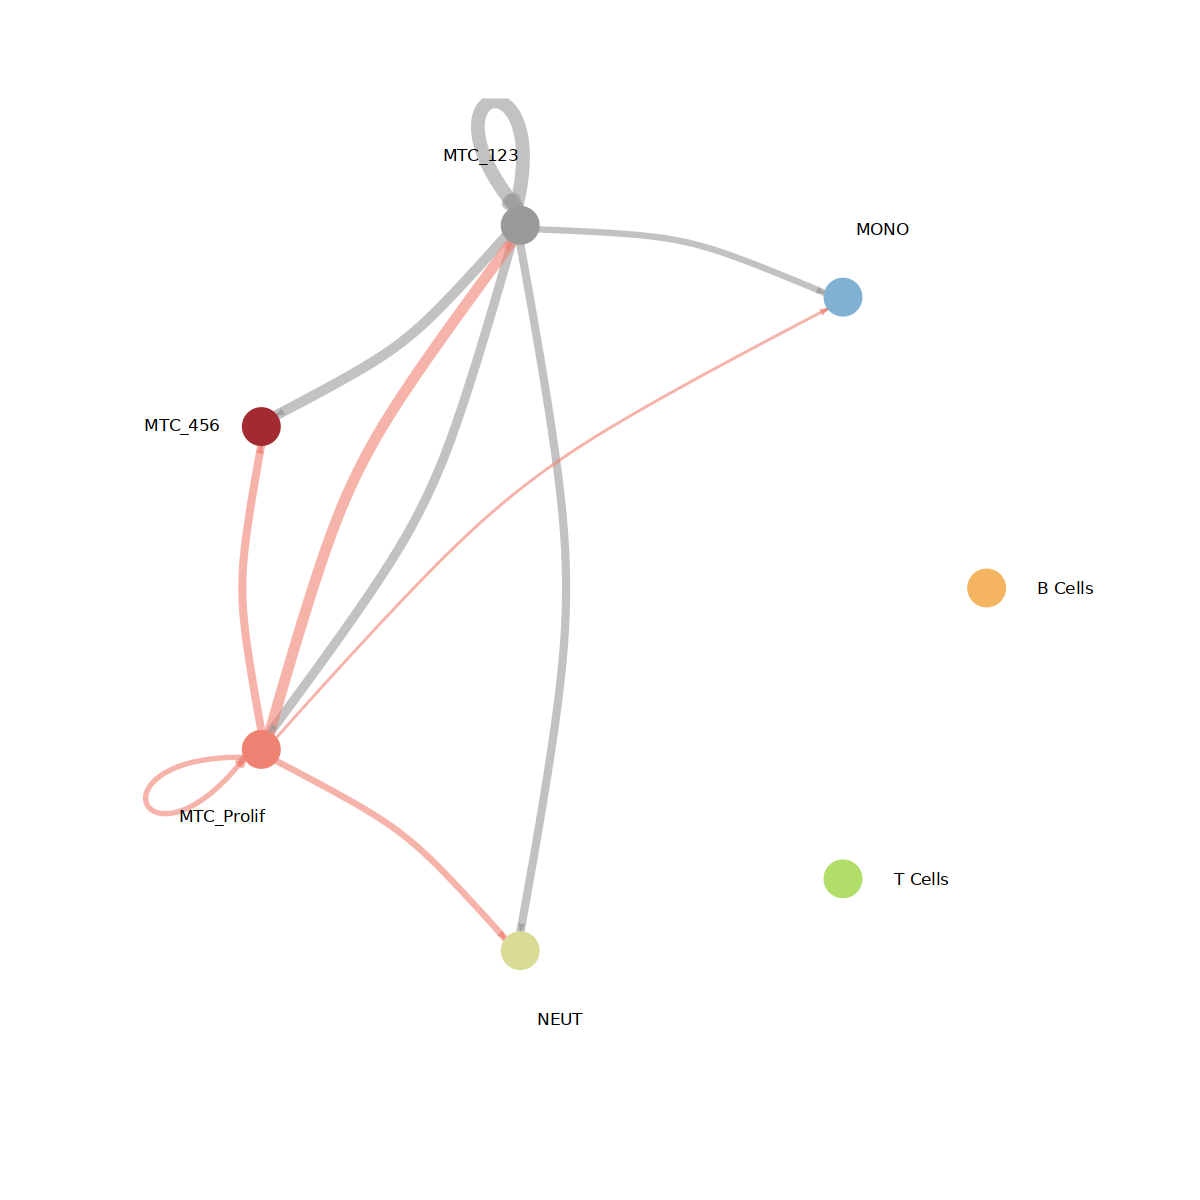

In [24]:
gg <- netVisual_aggregate(cellchat, signaling = "COMPLEMENT", layout = "circle",color.use=node_colors,)

In [25]:
class(gg)

[1] "recordedplot"

ERROR: Error in UseMethod("as.grob"): no applicable method for 'as.grob' applied to an object of class "recordedplot"


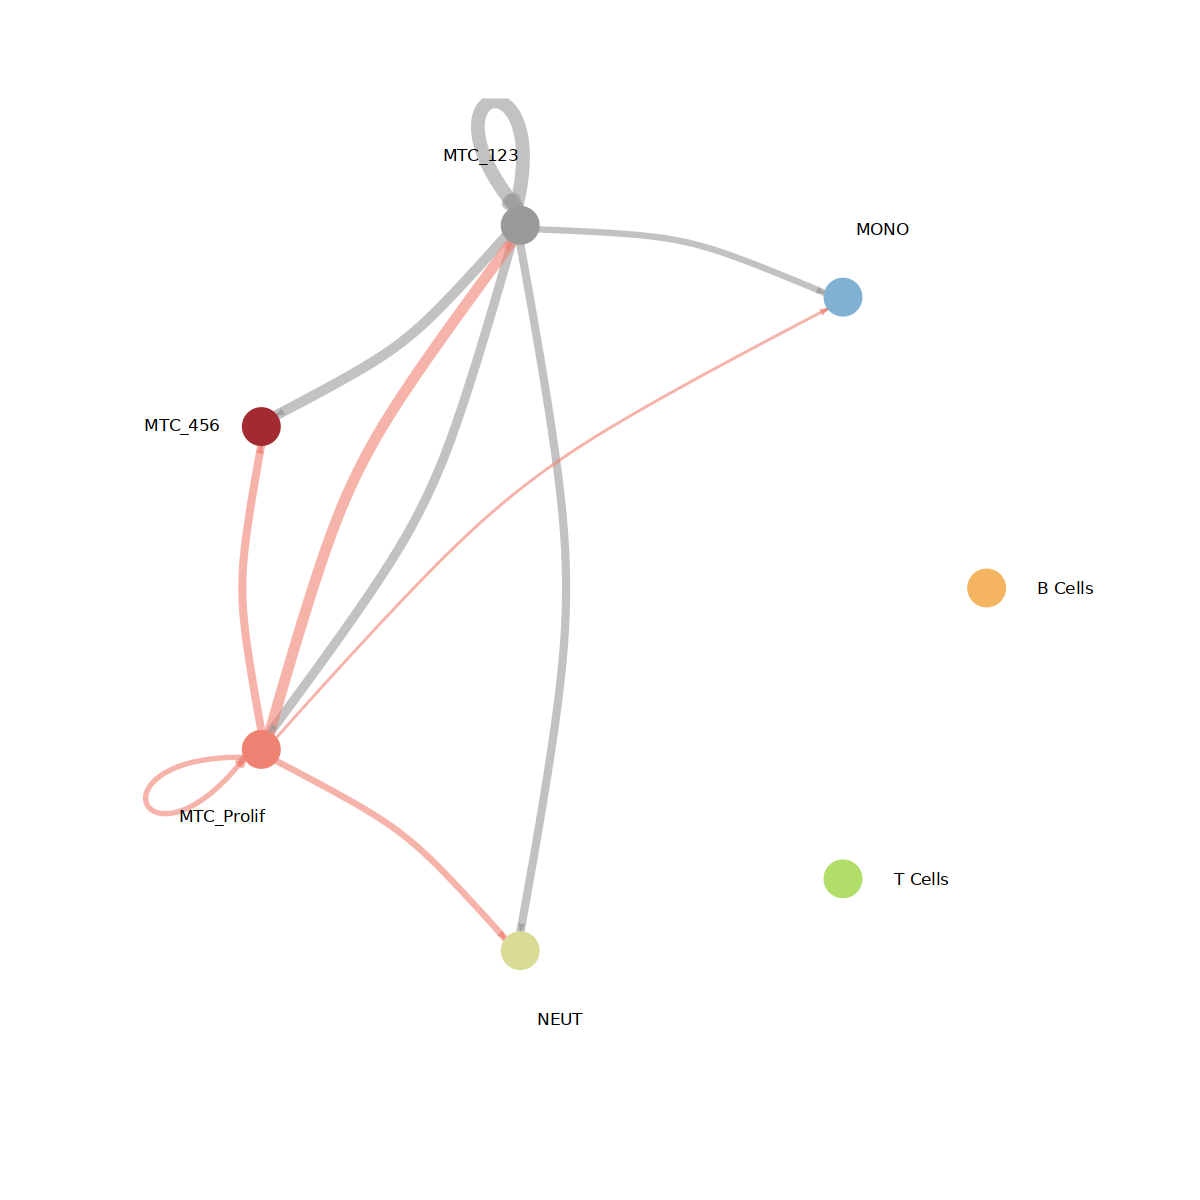

In [26]:
# png('CellChat_Complement2_Pathway.png')
library(ggplot2)
library("grid")
library("ggplotify")

gg <- as.ggplot(netVisual_aggregate(cellchat, signaling = "COMPLEMENT", layout = "circle",color.use=node_colors,))
# dev.off()

gg

In [68]:
library(svglite)

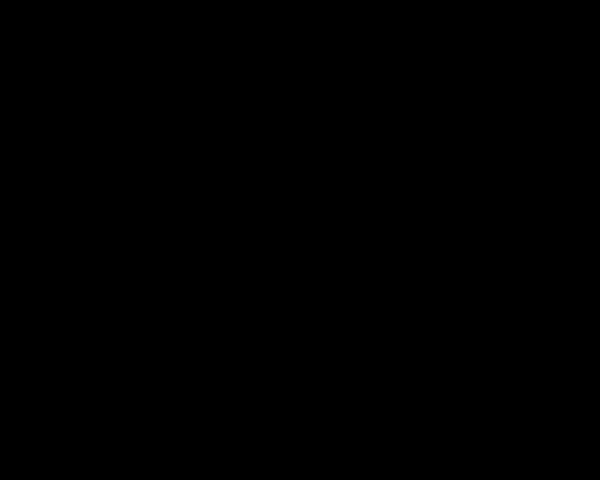

devSVG 
     3

In [71]:

svglite('CellChat_Complement_Pathway.pdf',width = 8,heigh = 8,)
netVisual_aggregate(cellchat, signaling = "COMPLEMENT", layout = "circle",color.use=node_colors)
dev.off()


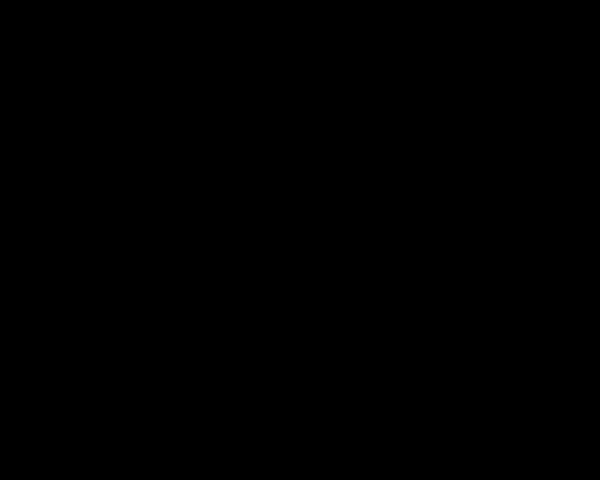

null device 
          1

In [81]:
graphics.off()

tiff('CellChat_Complement_Pathway.tiff')
netVisual_aggregate(cellchat, signaling = "COMPLEMENT", layout = "circle",color.use=node_colors,)
dev.off()
# dev.off()
# dev.off()

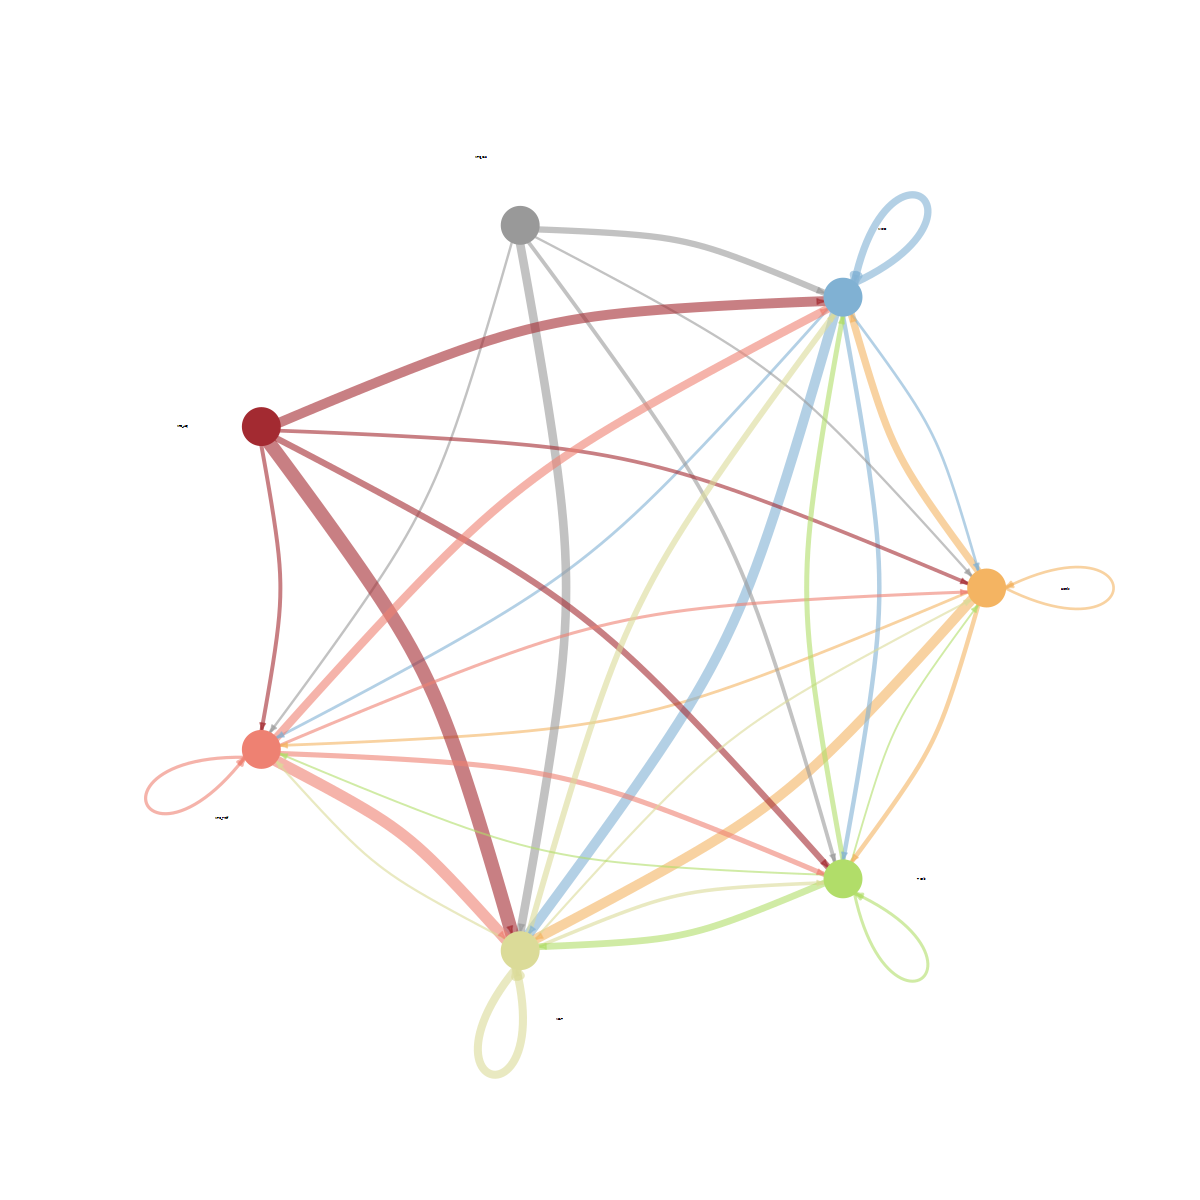

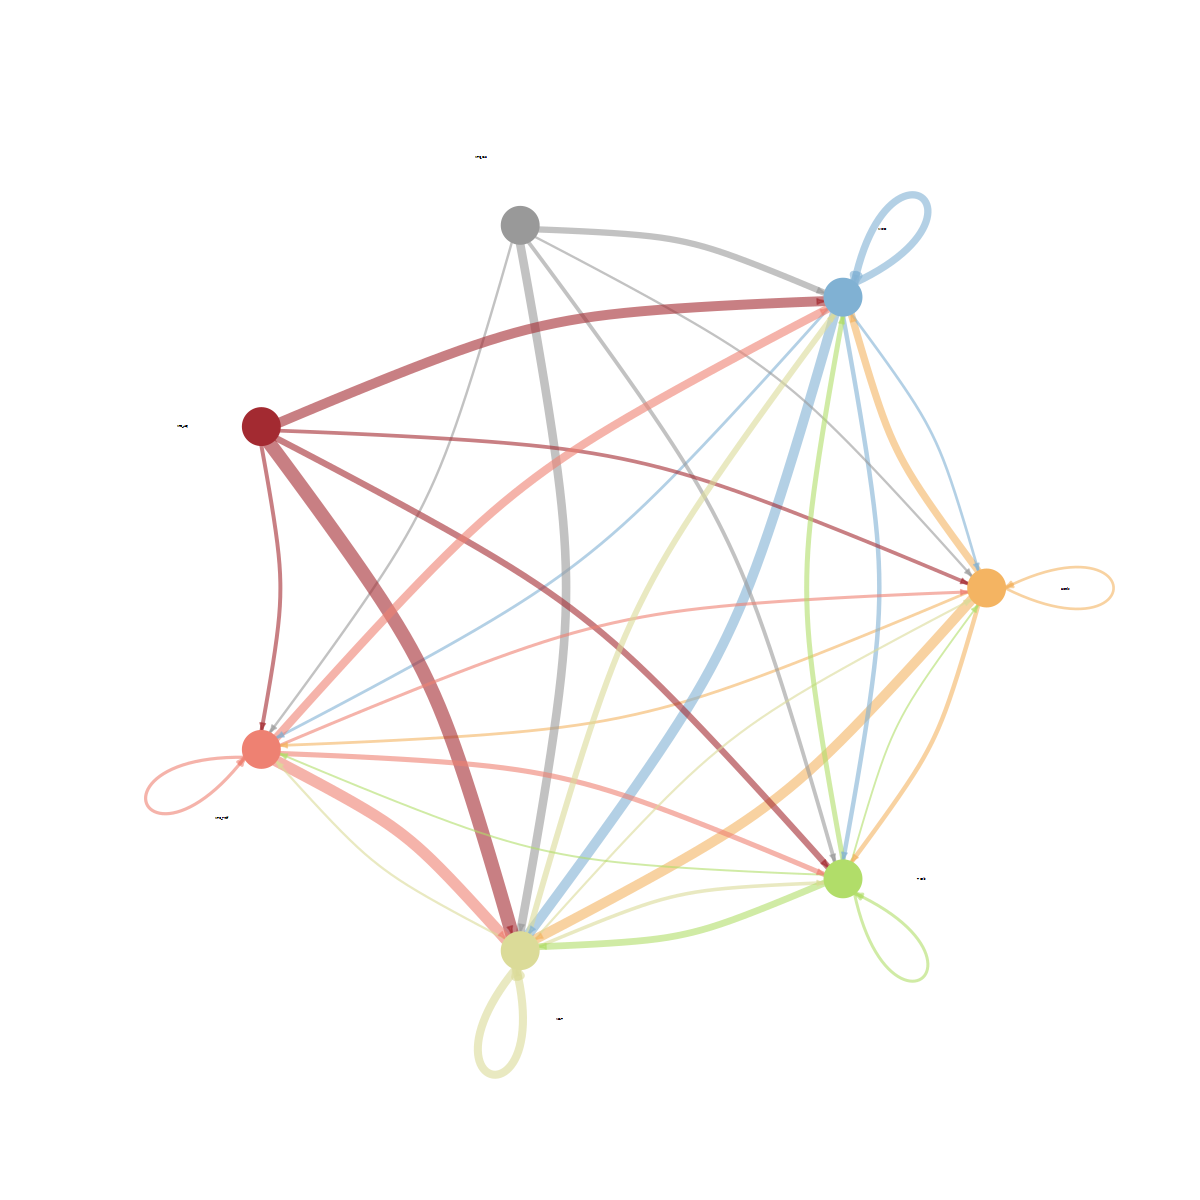

In [28]:
netVisual_aggregate(cellchat, signaling = "SPP1", layout = "circle",color.use=node_colors,vertex.label.cex = 0.1)


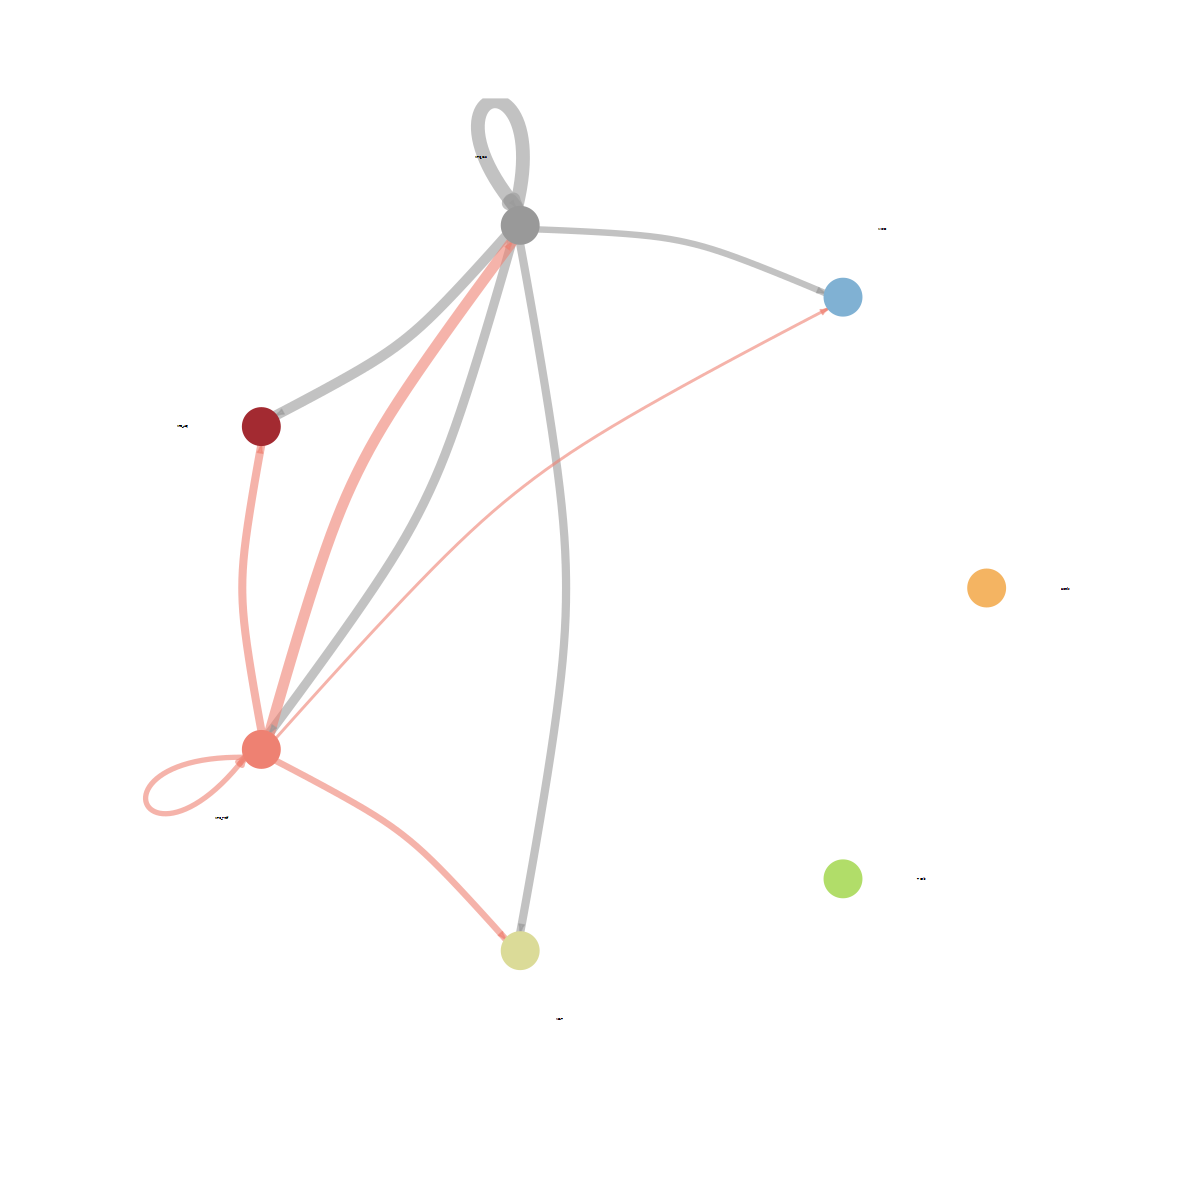

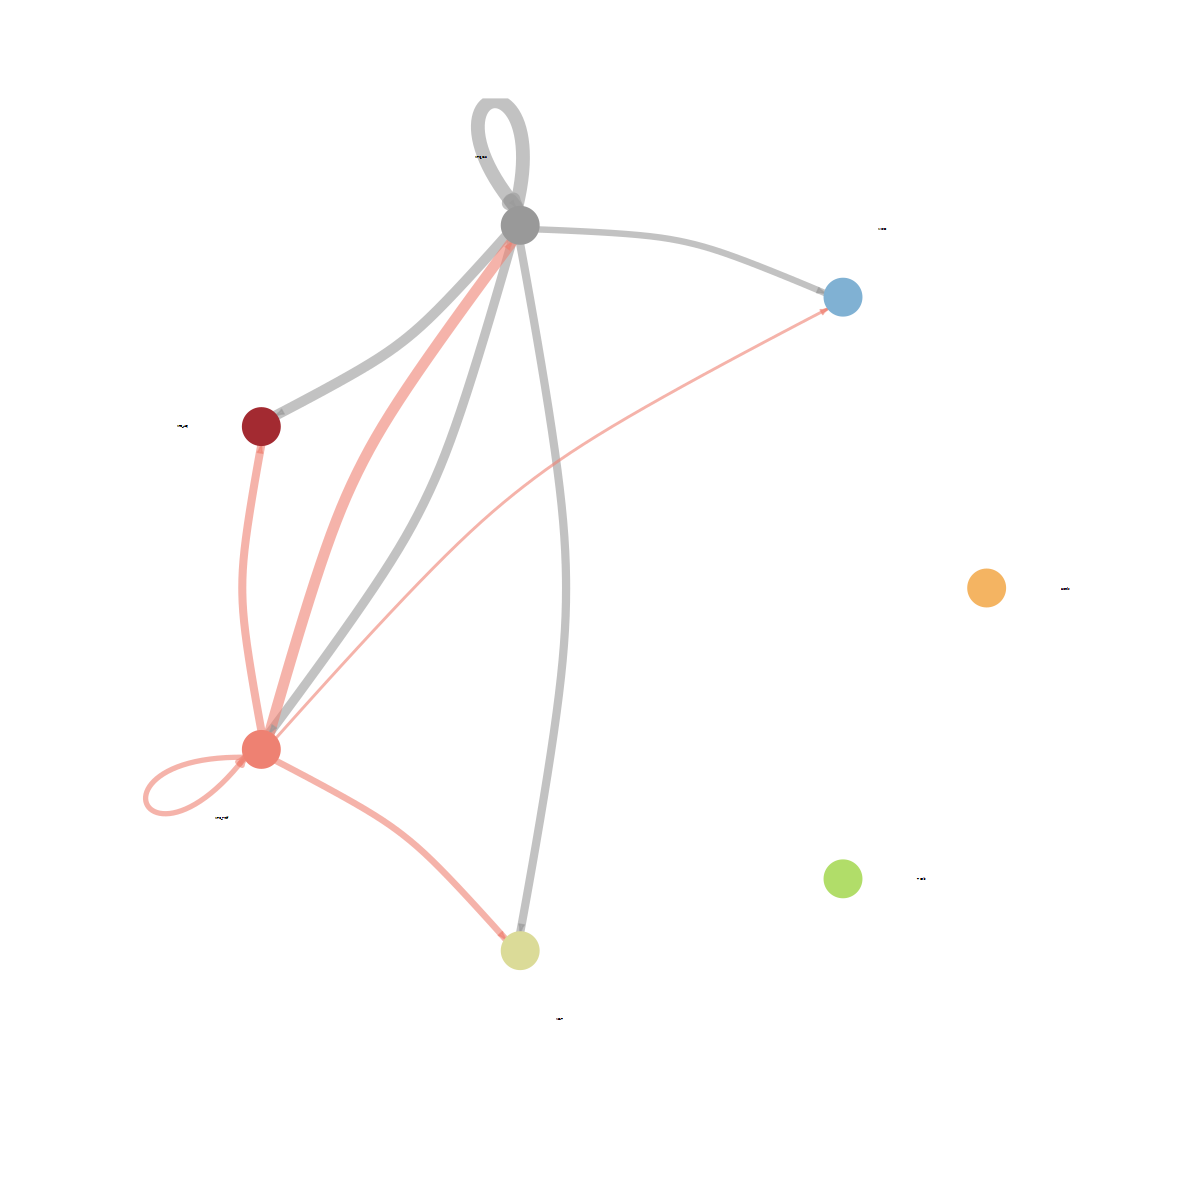

In [49]:
netVisual_aggregate(cellchat, signaling = "COMPLEMENT", layout = "circle",color.use=node_colors,vertex.label.cex = 0.1)


In [ ]:
options(repr.plot.width=10, repr.plot.height=10)
graphics.off()

pdf('Figures/Figure3_C_Complement_Pathway.pdf')
netVisual_aggregate(cellchat, signaling = "COMPLEMENT", layout = "circle",color.use=node_colors,vertex.label.cex = 0)
dev.off()

pdf('Figures/Figure3_C_Spp1_Pathway.pdf')
netVisual_aggregate(cellchat, signaling = "SPP1", layout = "circle",color.use=node_colors,vertex.label.cex = 0)
dev.off()

pdf('Figures/Figure3_C_Apoe_Pathway.pdf')
netVisual_aggregate(cellchat, signaling = 'ApoE', layout = "circle",color.use=node_colors,vertex.label.cex = 0)
dev.off()

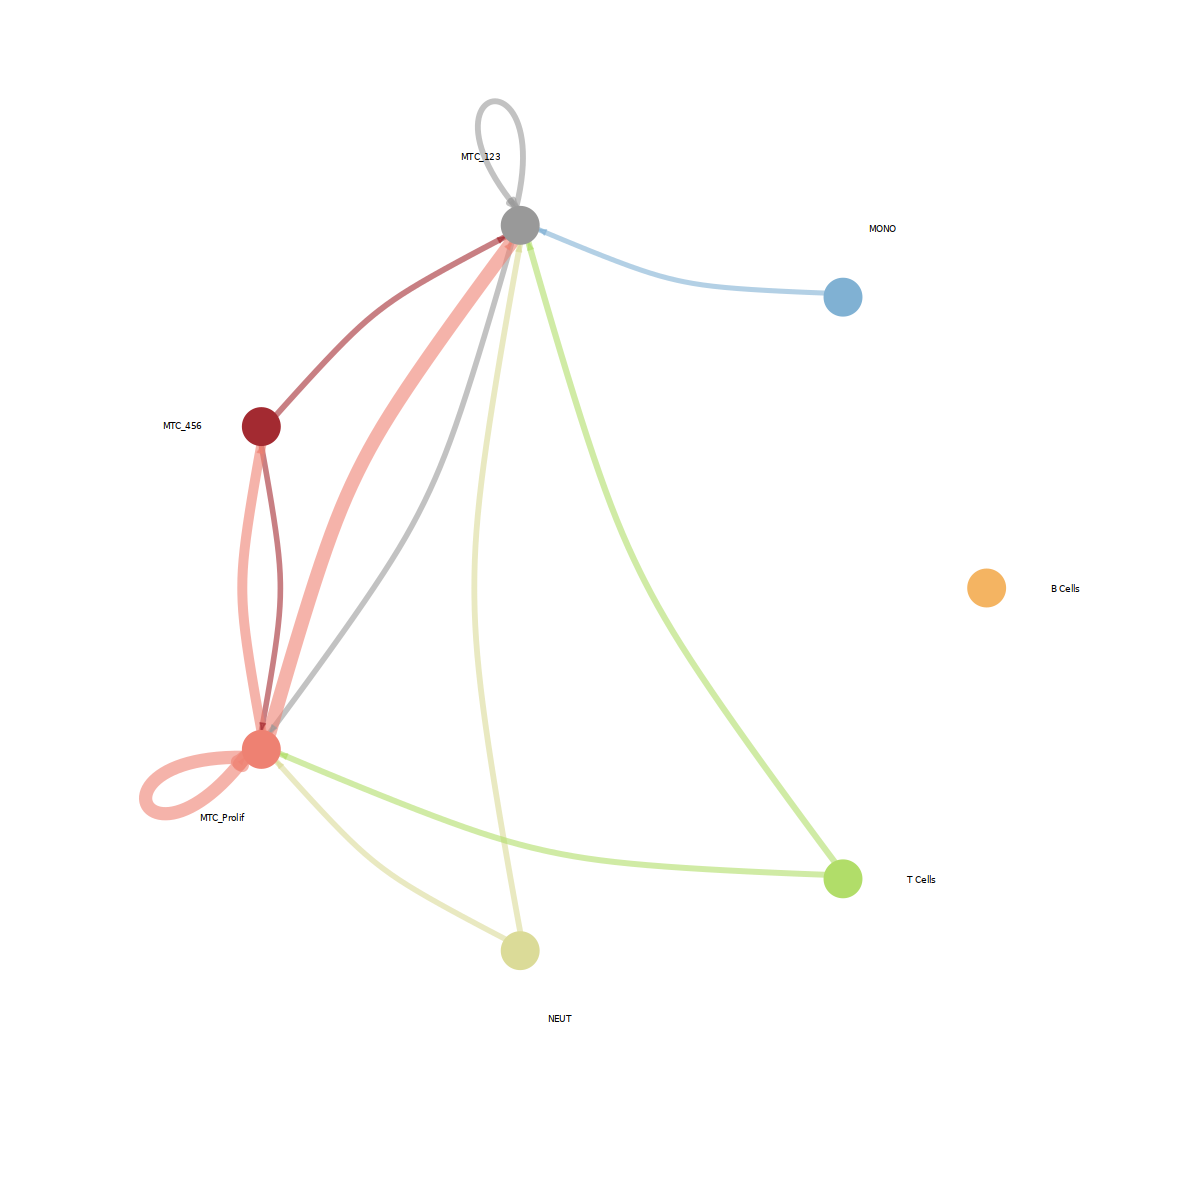

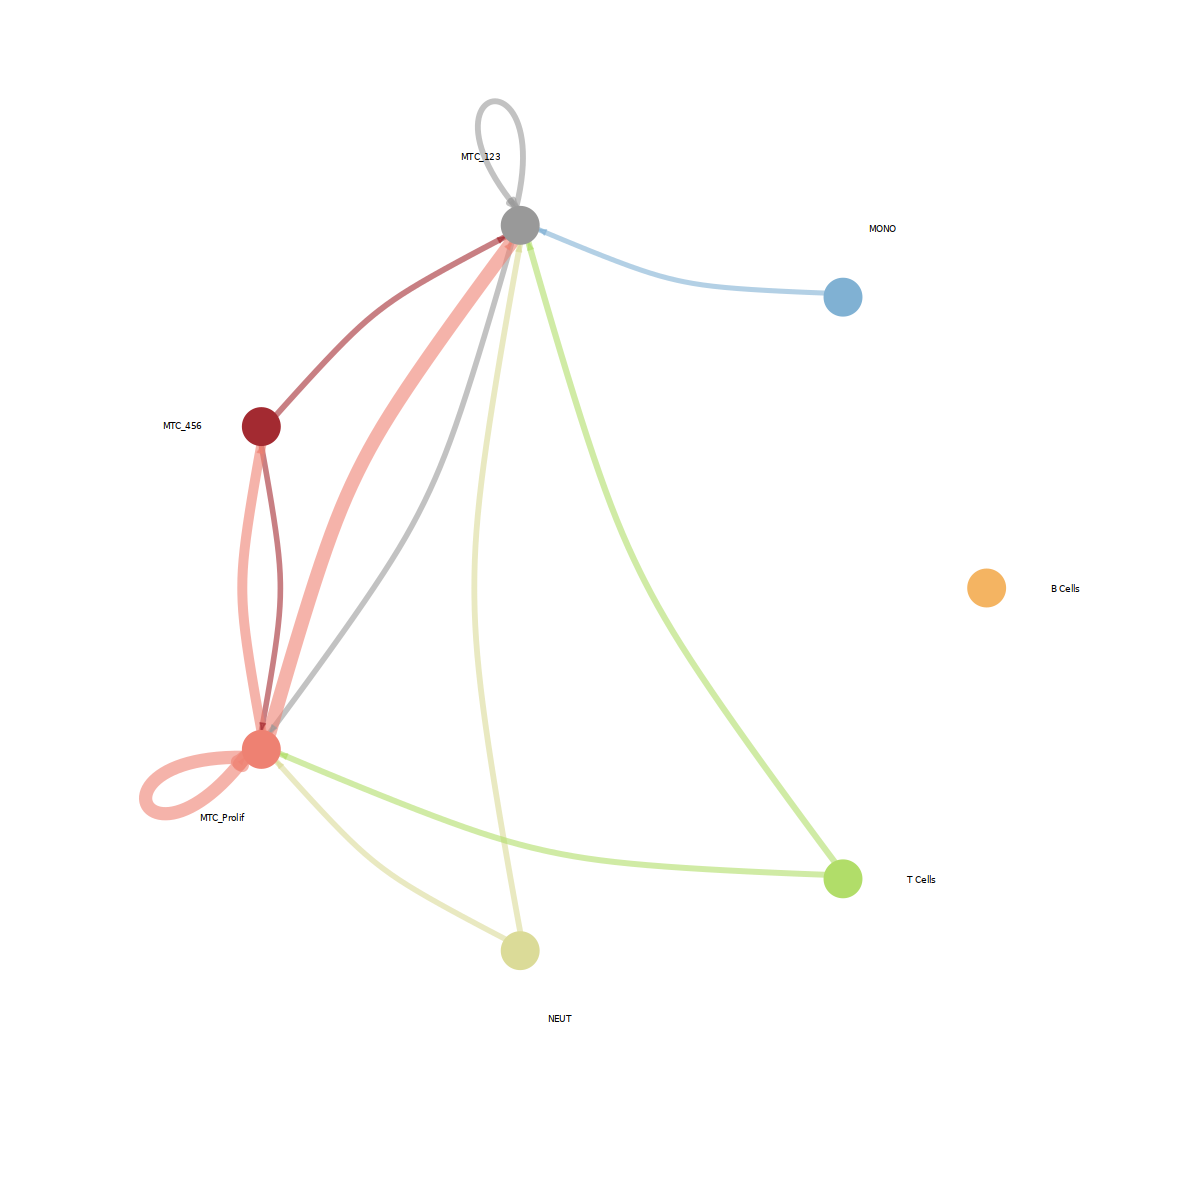

In [50]:
netVisual_aggregate(cellchat, 
                    signaling = pathways.show, 
                    layout = "circle",
                    color.use=node_colors,
                    vertex.label.cex = 0.4)

In [46]:
dev.off()
dev.off()
dev.off()
dev.off()
dev.off()
dev.off()

png 
  5

png 
  6

png 
  7

null device 
          1

ERROR: Error in dev.off(): cannot shut down device 1 (the null device)


In [ ]:
pdf('CellChat_Complement_Pathway.pdf')
netVisual_aggregate(cellchat, signaling = "COMPLEMENT", layout = "circle",color.use=node_colors,)
dev.off()
netVisual_aggregate(cellchat, signaling = "COMPLEMENT", layout = "circle",color.use=node_colors,)


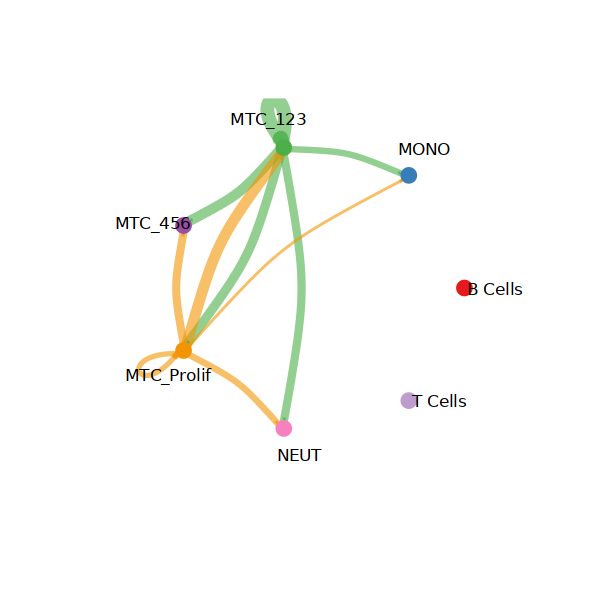

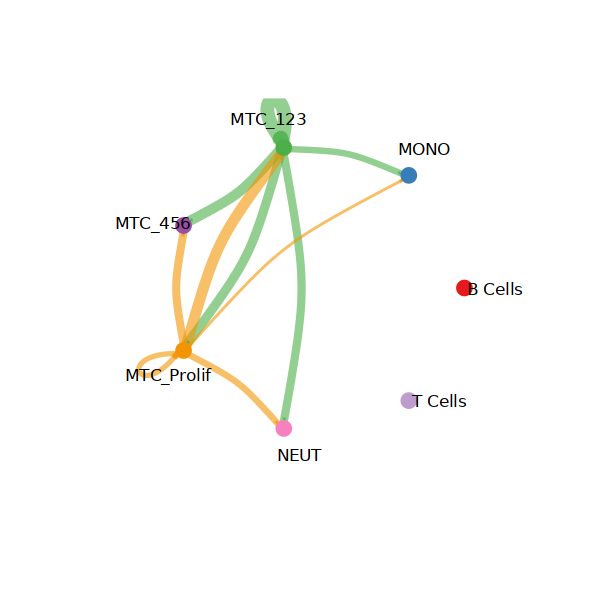

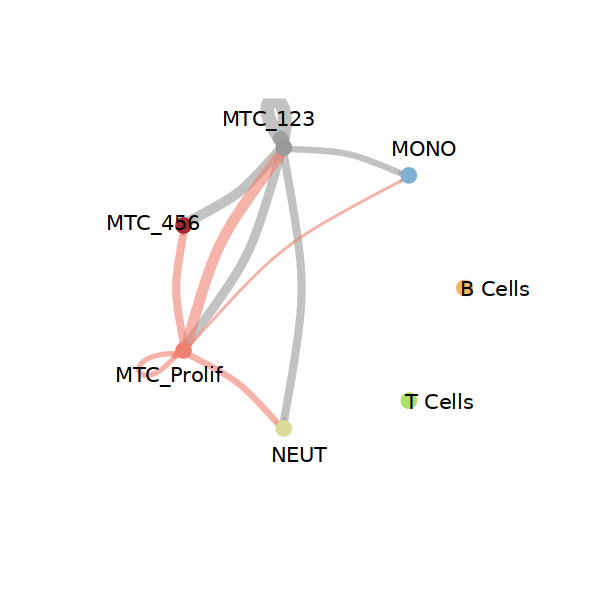

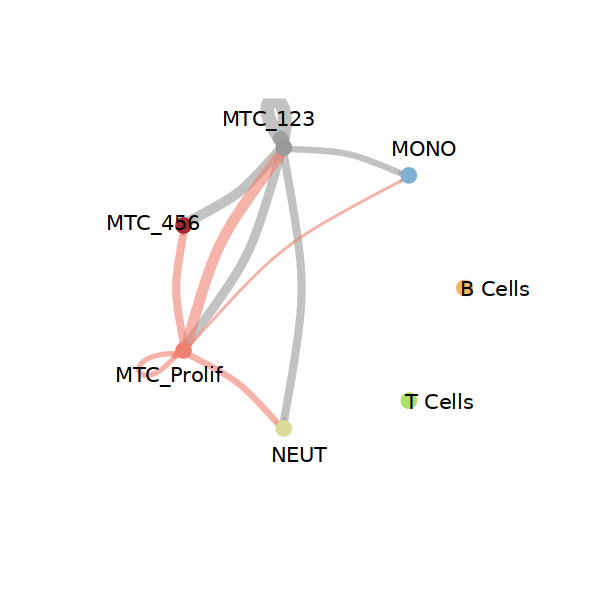

In [30]:
options(repr.plot.width=5, repr.plot.height=5)
pathways.show <- c("COMPLEMENT") 
# Hierarchy plot
# Here we define `vertex.receive` so that the left portion of the hierarchy plot shows signaling to fibroblast and the right portion shows signaling to immune cells 
vertex.receiver = seq(1,4) # a numeric vector. 
netVisual_aggregate(cellchat, signaling = pathways.show,  vertex.receiver = vertex.receiver)
# Circle plot
par(mfrow=c(1,1))
netVisual_aggregate(cellchat, signaling = pathways.show, layout = "circle",color.use=node_colors,vertex.label.cex = 0)

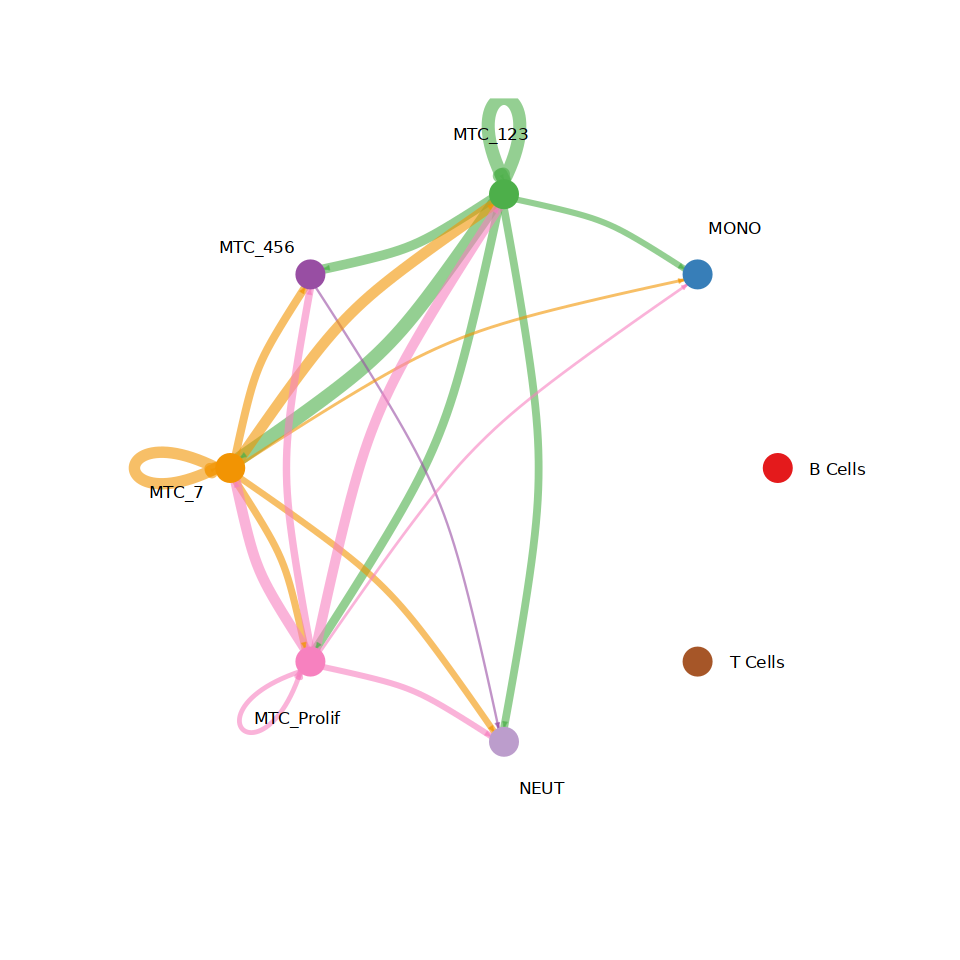

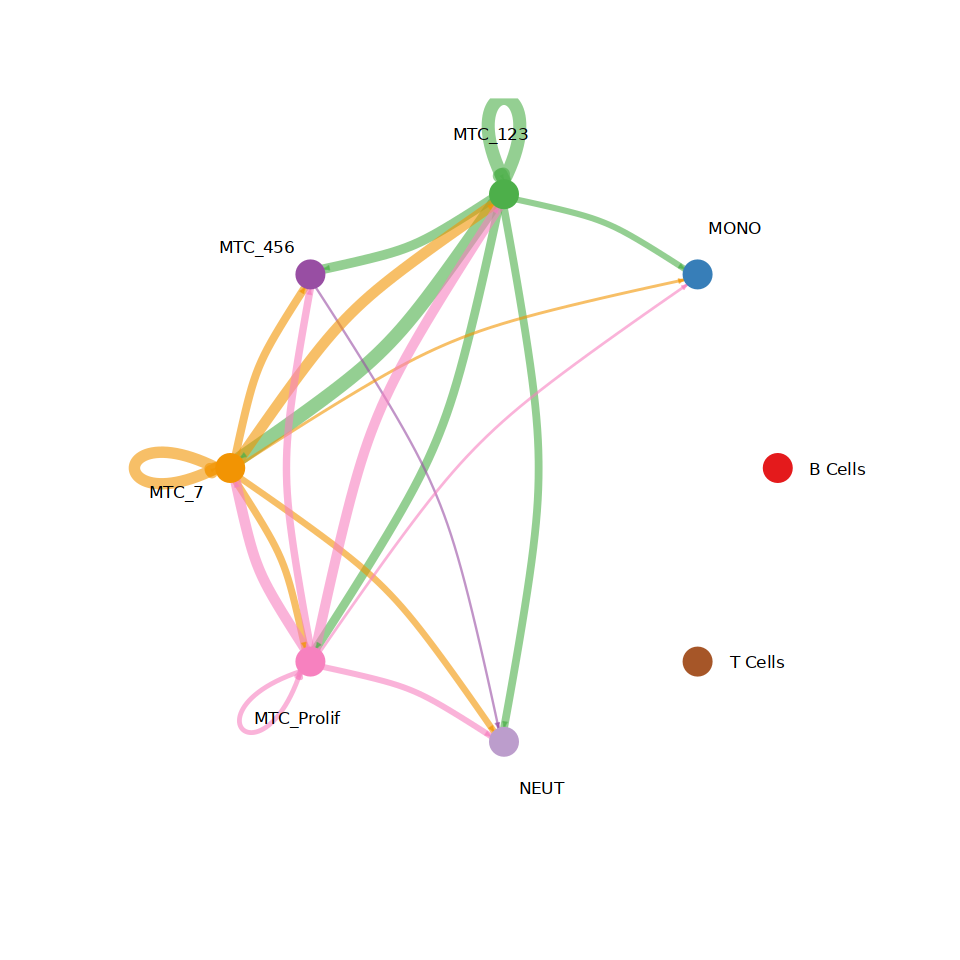

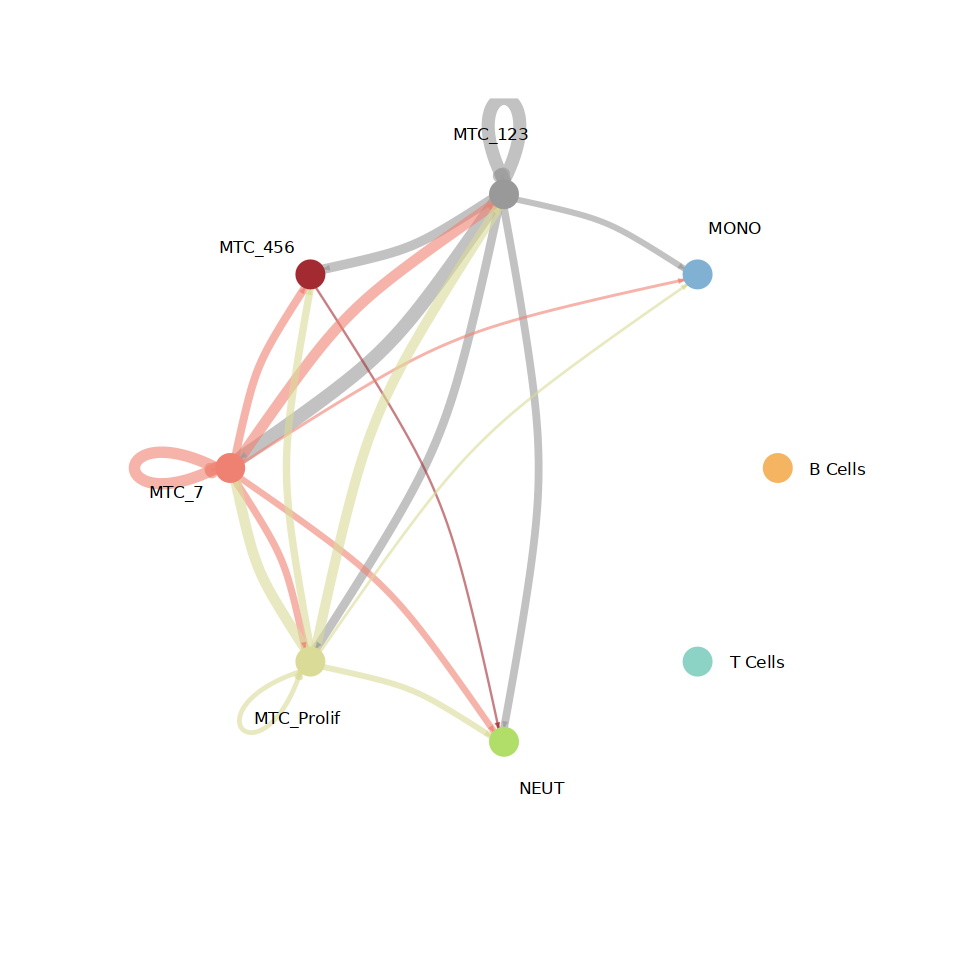

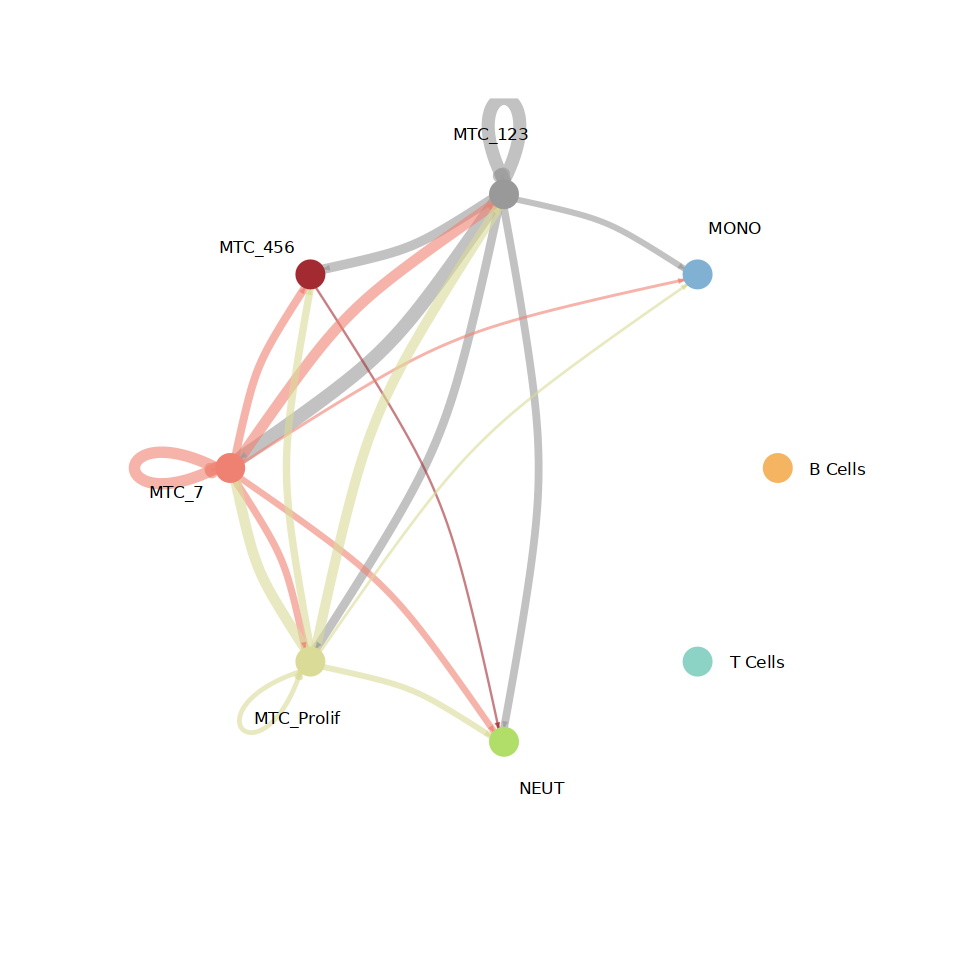

In [33]:
options(repr.plot.width=8, repr.plot.height=8)
pathways.show <- c("COMPLEMENT") 
# Hierarchy plot
# Here we define `vertex.receive` so that the left portion of the hierarchy plot shows signaling to fibroblast and the right portion shows signaling to immune cells 
vertex.receiver = seq(1,4) # a numeric vector. 
netVisual_aggregate(cellchat, signaling = pathways.show,  vertex.receiver = vertex.receiver)
# Circle plot
par(mfrow=c(1,1))
netVisual_aggregate(cellchat, signaling = pathways.show, layout = "circle",color.use=node_colors,)

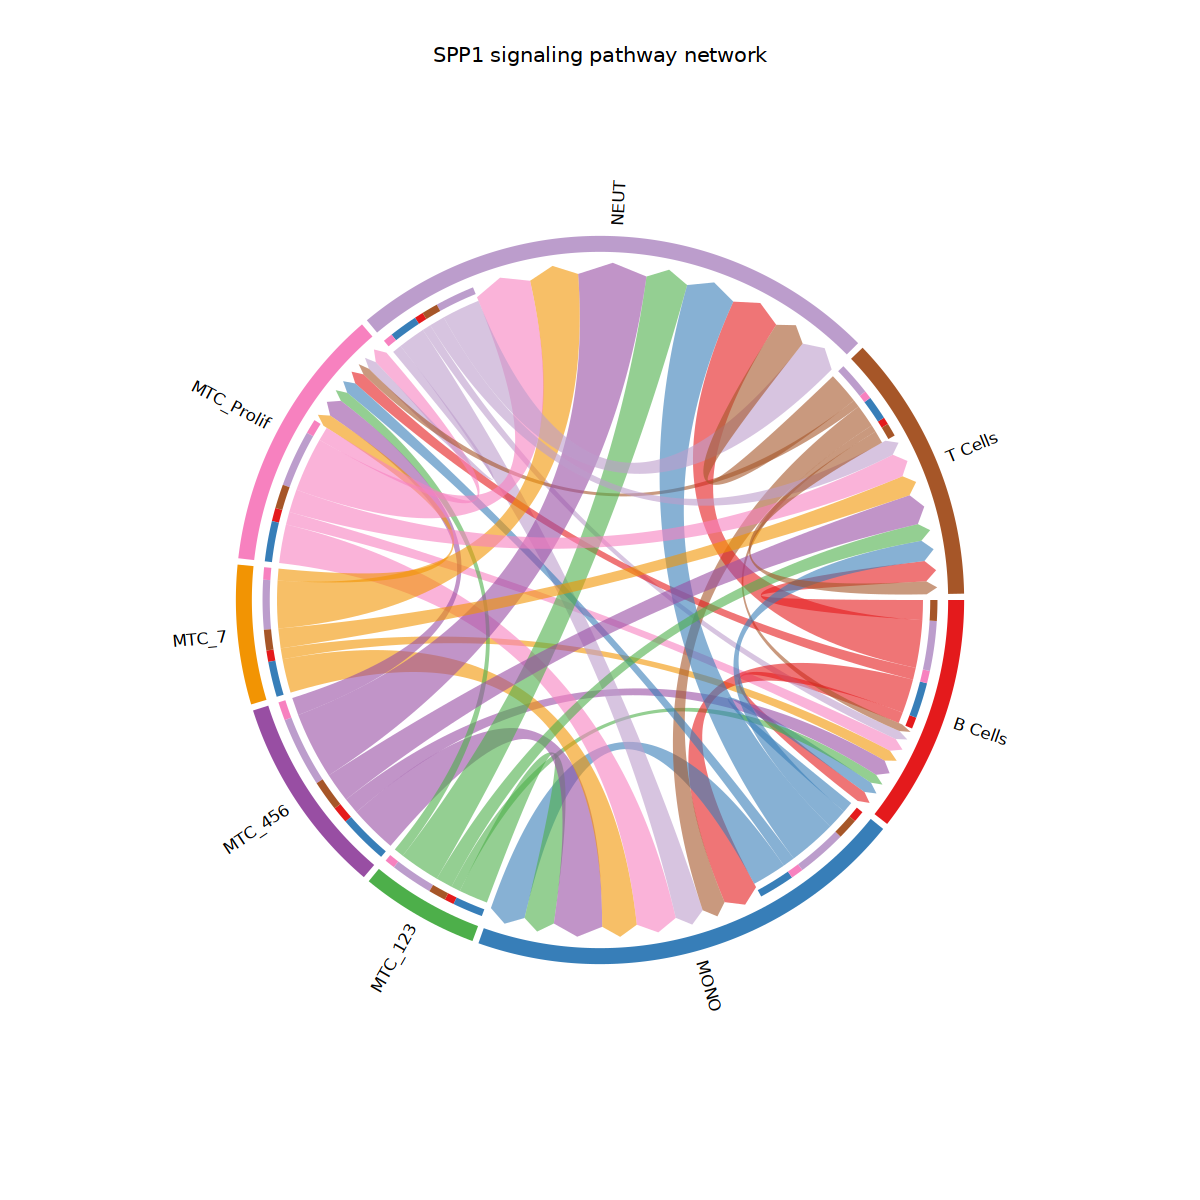

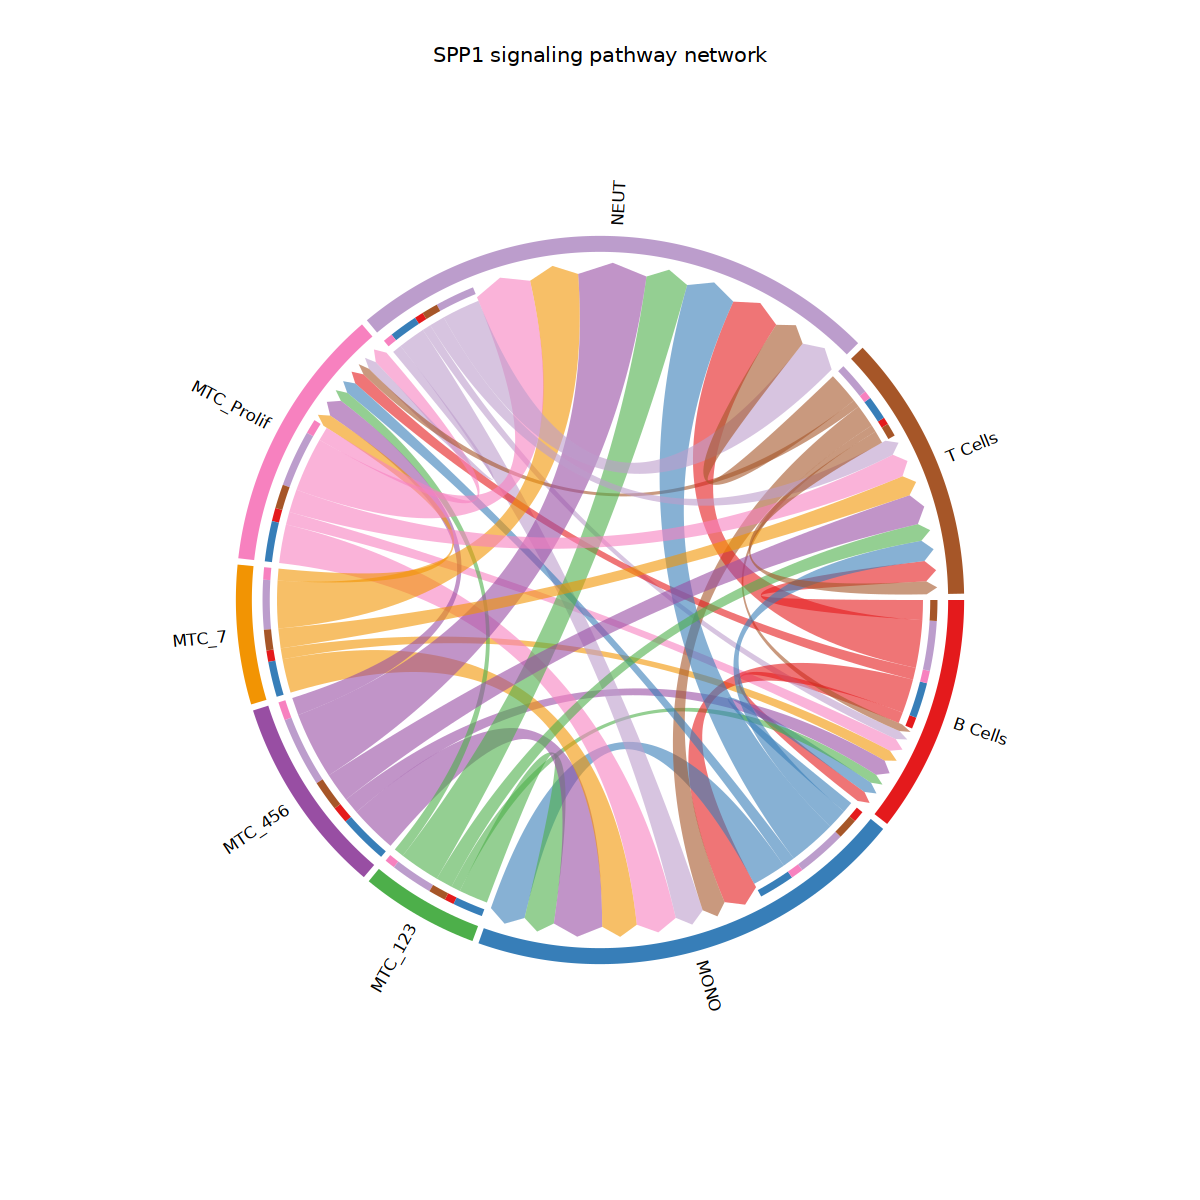

In [52]:
# Chord diagram
par(mfrow=c(1,1))
netVisual_aggregate(cellchat, signaling = pathways.show, layout = "chord")

Do heatmap based on a single object 




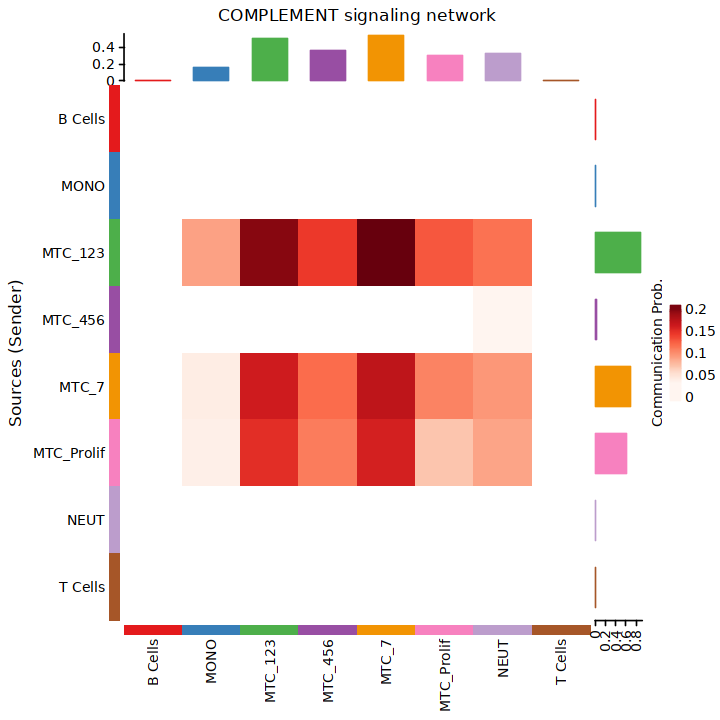

In [124]:
options(repr.plot.width=6, repr.plot.height=6)
# Heatmap
par(mfrow=c(1,1))
netVisual_heatmap(cellchat, signaling = 'COMPLEMENT', color.heatmap = "Reds")

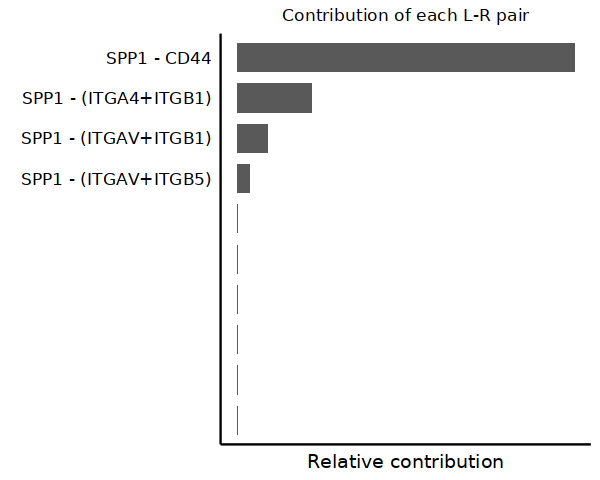

In [40]:
options(repr.plot.width=5, repr.plot.height=4)
netAnalysis_contribution(cellchat, signaling = 'SPP1')


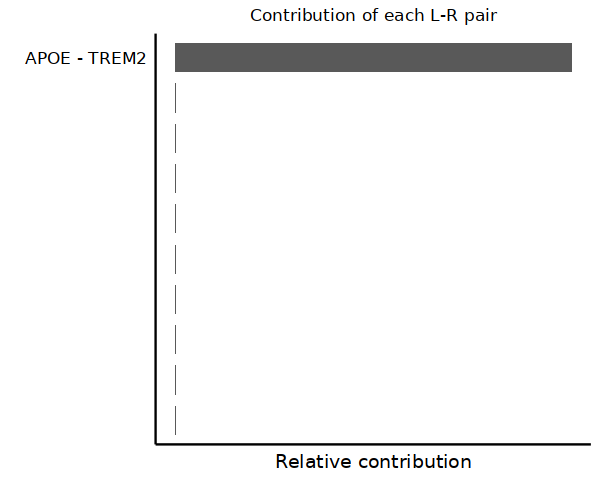

In [39]:
options(repr.plot.width=5, repr.plot.height=4)
netAnalysis_contribution(cellchat, signaling = 'ApoE')


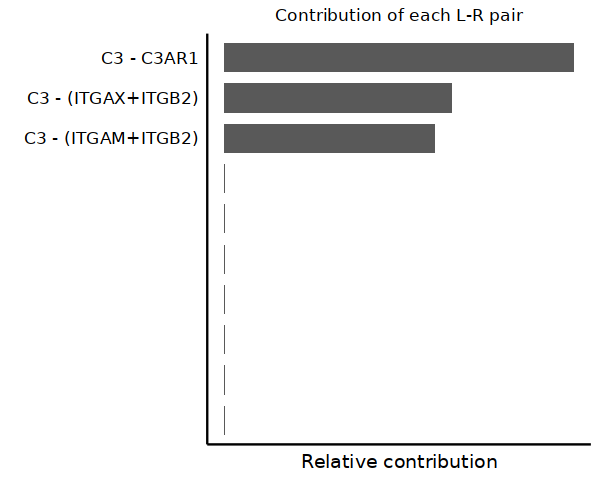

In [31]:
options(repr.plot.width=5, repr.plot.height=4)
netAnalysis_contribution(cellchat, signaling = 'COMPLEMENT')


[[1]]


[[1]]


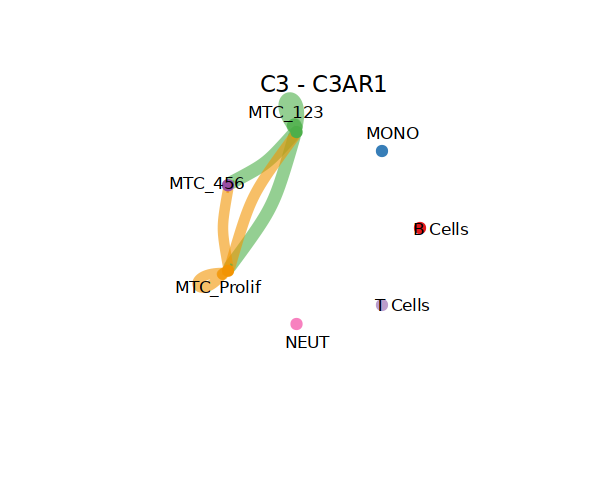

In [32]:
pairLR.CXCL <- extractEnrichedLR(cellchat, signaling = pathways.show, geneLR.return = FALSE)
LR.show <- pairLR.CXCL[1,] # show one ligand-receptor pair
# Hierarchy plot
vertex.receiver = seq(1,4) # a numeric vector
netVisual_individual(cellchat, signaling = pathways.show,  pairLR.use = LR.show, vertex.receiver = vertex.receiver)
#> [[1]]
# Circle plot
netVisual_individual(cellchat, signaling = pathways.show, pairLR.use = LR.show, layout = "circle")

Comparing communications on a single object 




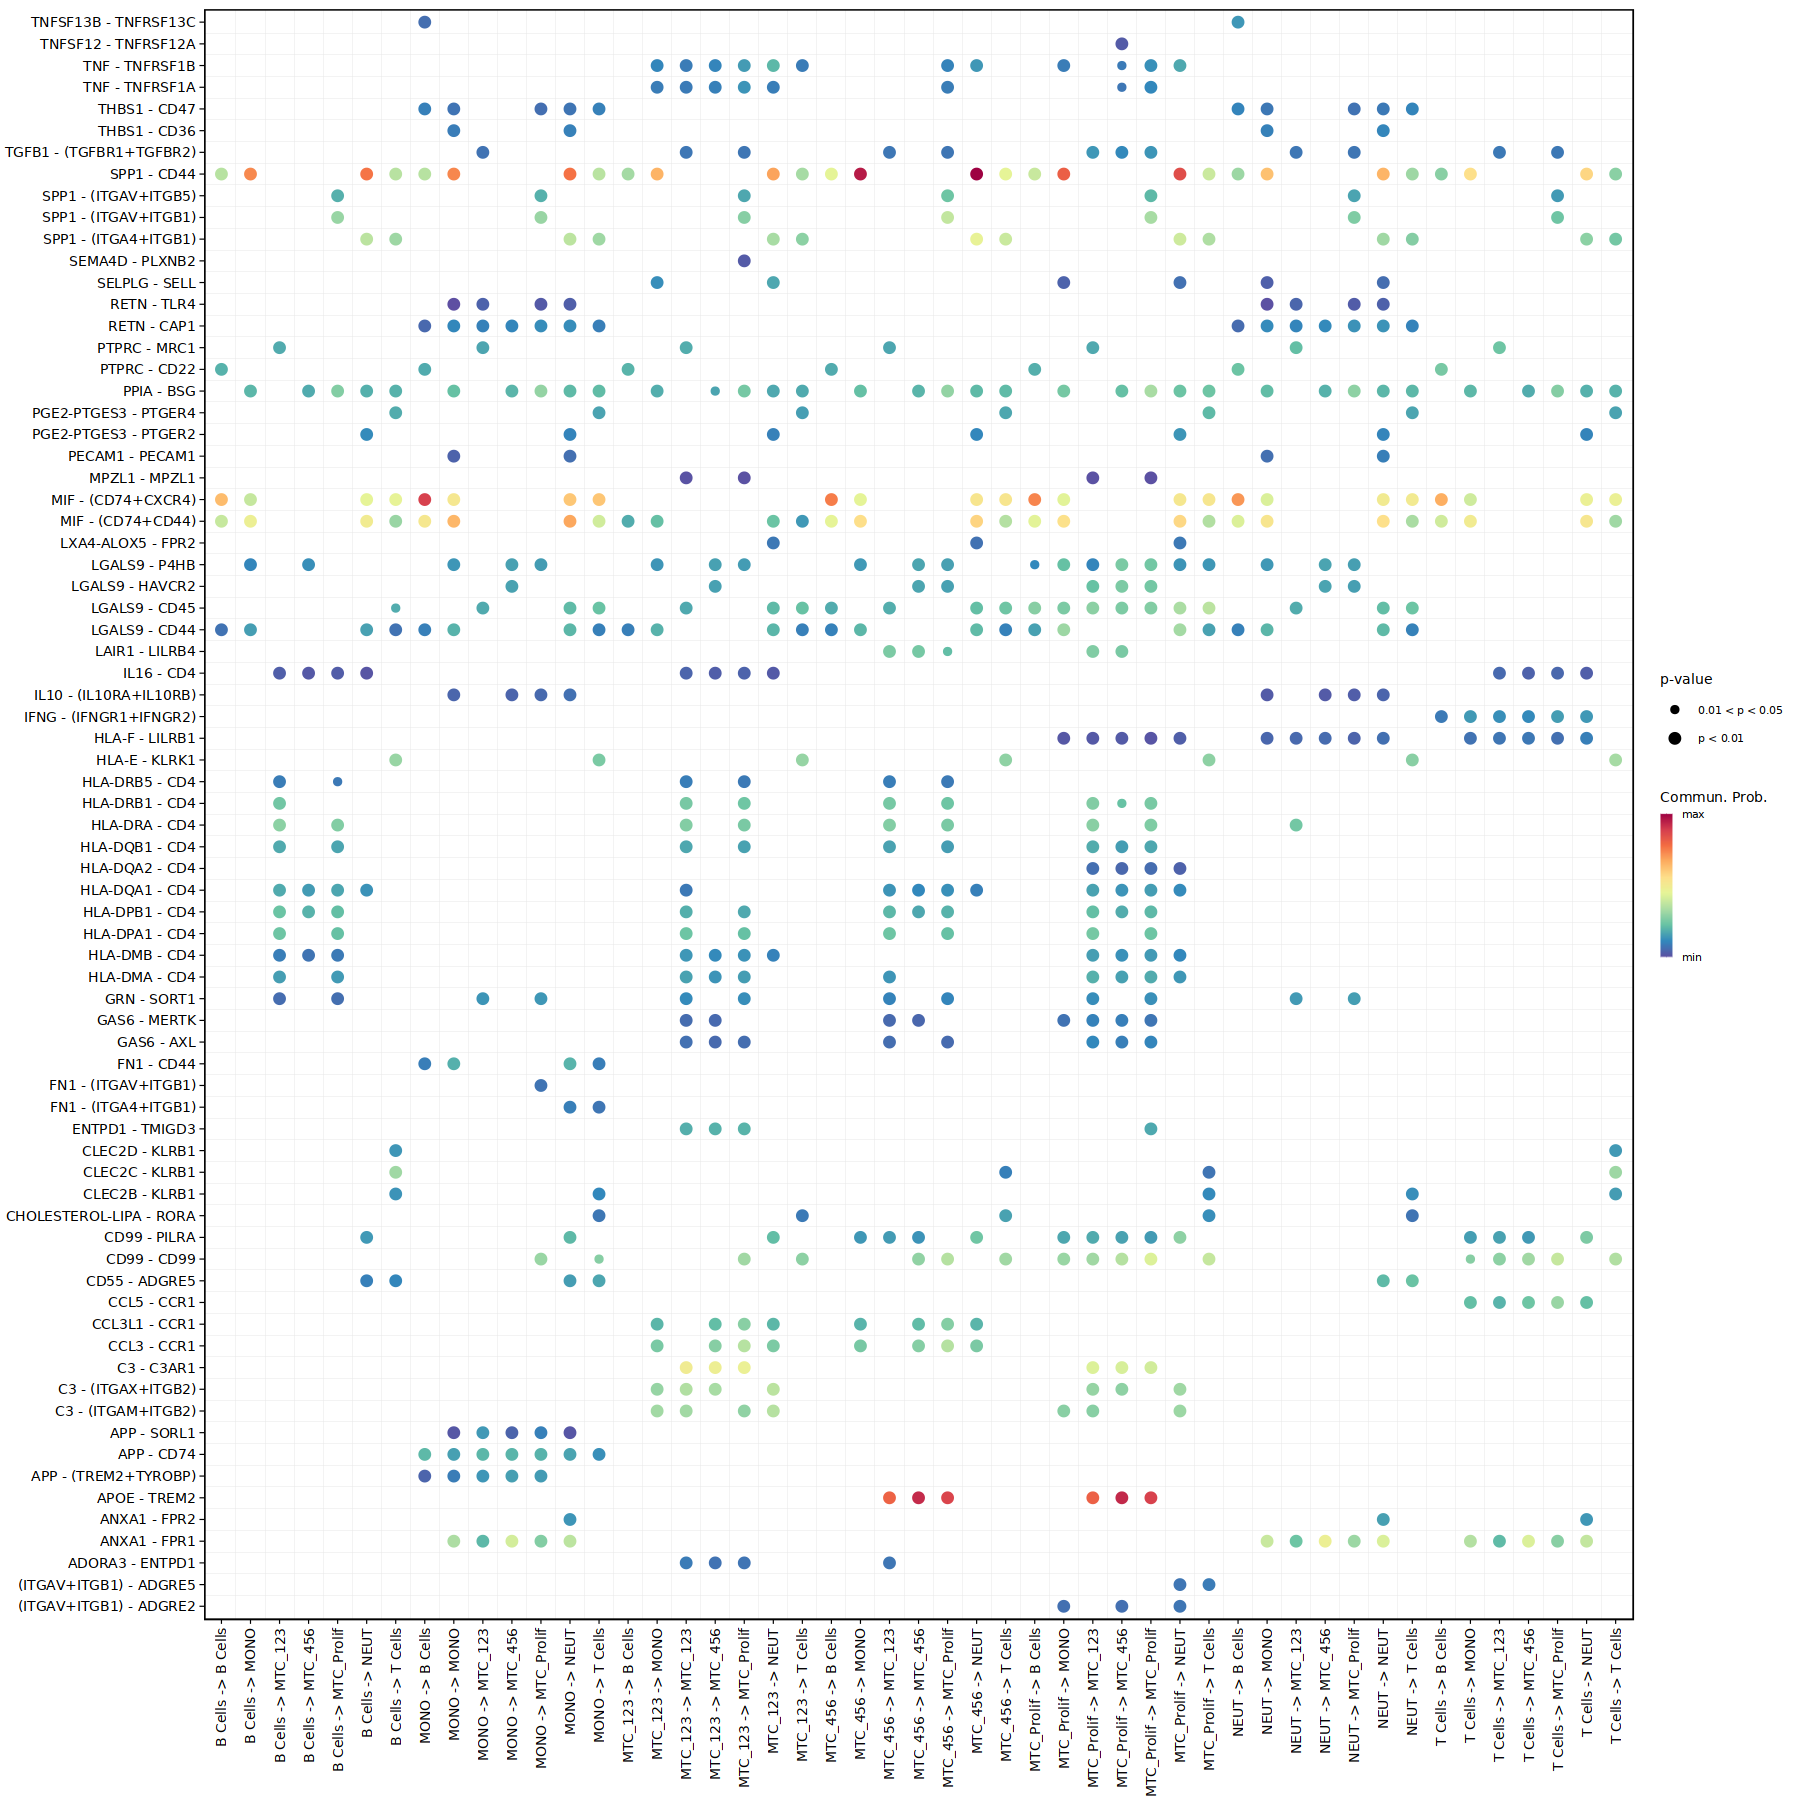

In [33]:
options(repr.plot.width=15, repr.plot.height=15)
# (1) show all the significant interactions (L-R pairs) from some cell groups (defined by 'sources.use') to other cell groups (defined by 'targets.use')
netVisual_bubble(cellchat, , remove.isolate = FALSE)
#> Comparing communications on a single object

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


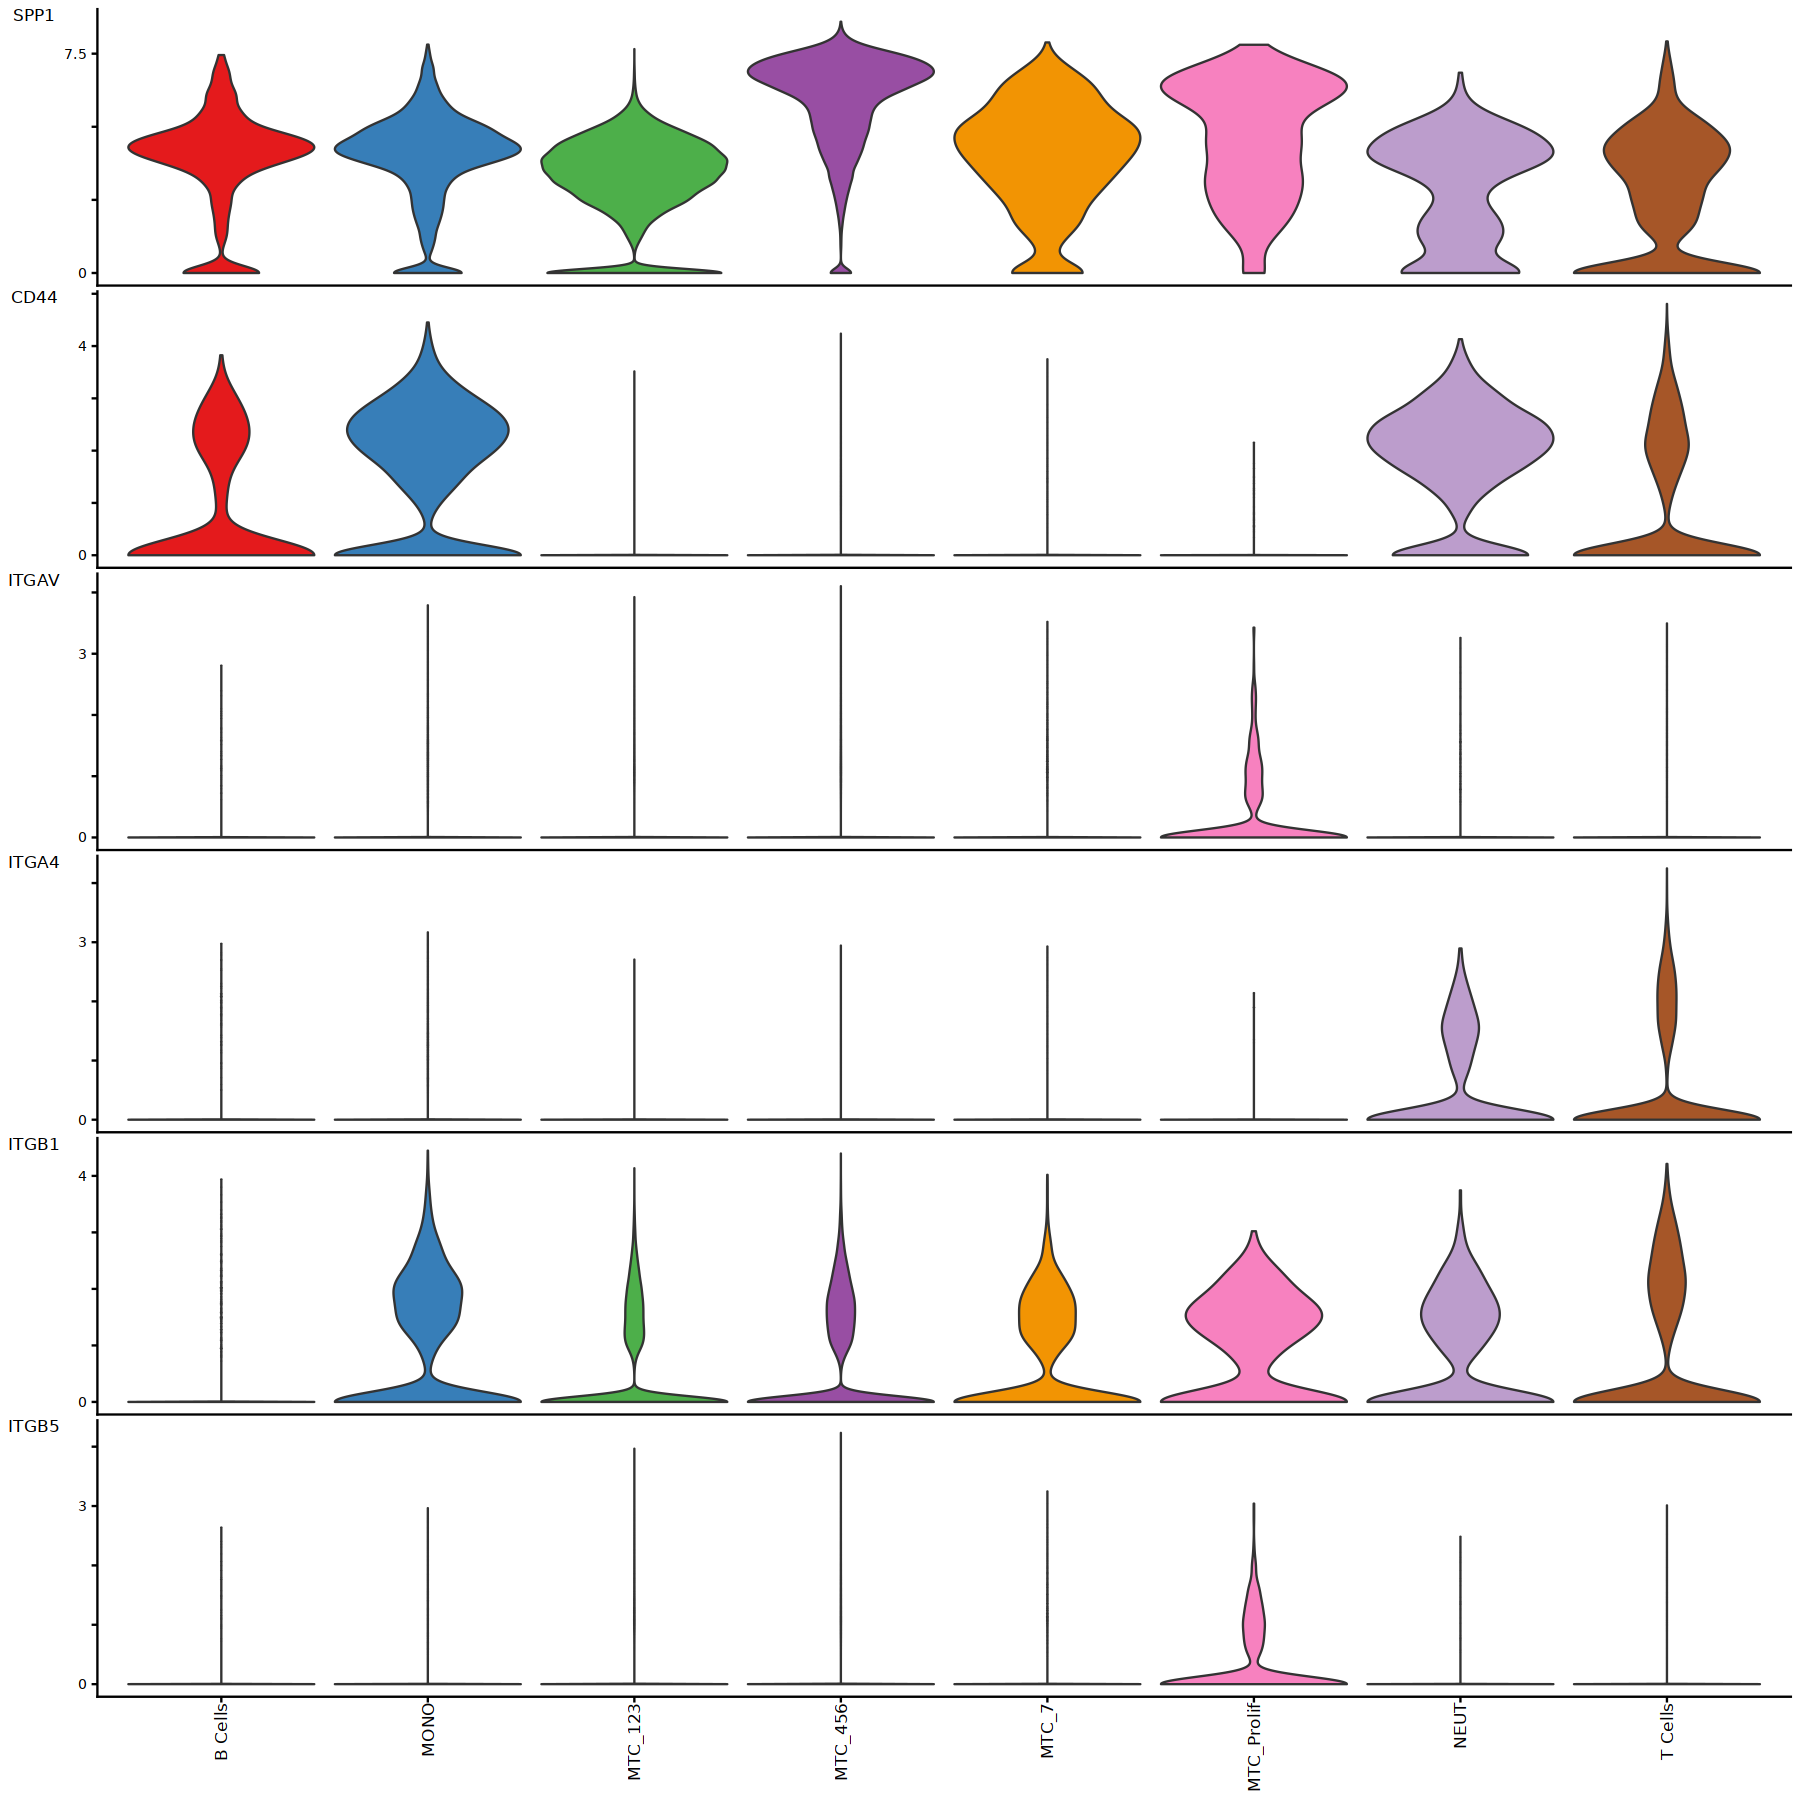

In [65]:
plotGeneExpression(cellchat, signaling = "SPP1", enriched.only = TRUE, type = "violin")


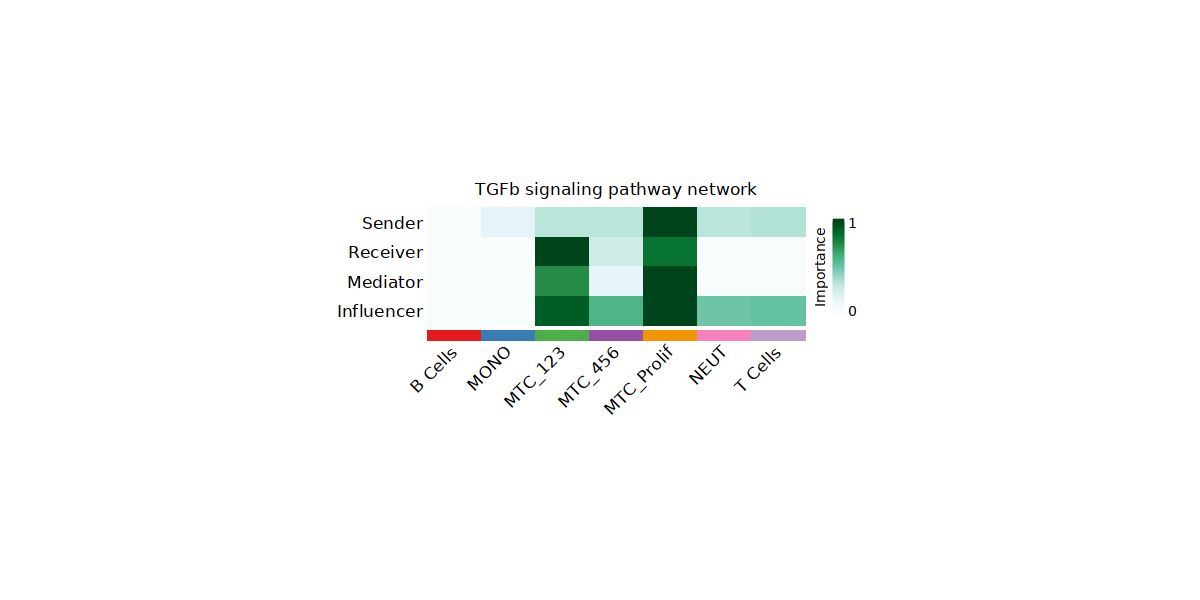

In [43]:
pathways.show <- c("TGFb") 

options(repr.plot.width=10, repr.plot.height=5)
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP") # the slot 'netP' means the inferred intercellular communication network of signaling pathways
# Visualize the computed centrality scores using heatmap, allowing ready identification of major signaling roles of cell groups
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show, width = 8, height = 2.5, font.size = 10)

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Signaling role analysis on the cell-cell communication network from user's input



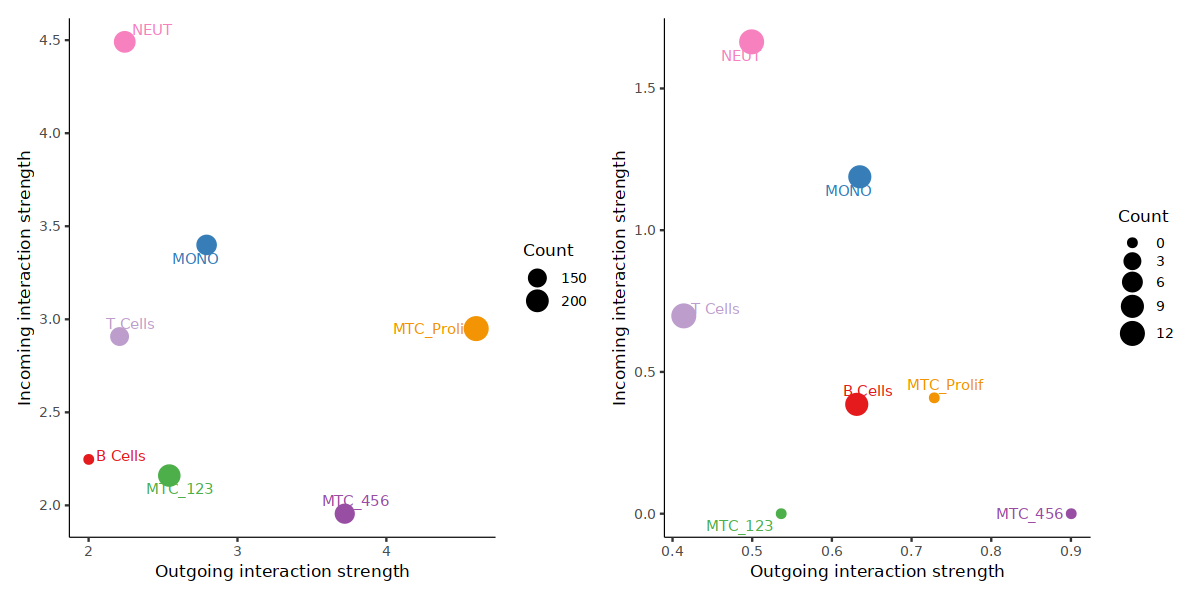

In [44]:
options(repr.plot.width=10, repr.plot.height=5)
# Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
gg1 <- netAnalysis_signalingRole_scatter(cellchat)
#> Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
# Signaling role analysis on the cell-cell communication networks of interest
gg2 <- netAnalysis_signalingRole_scatter(cellchat, signaling = c("SPP1", "APOE"))
#> Signaling role analysis on the cell-cell communication network from user's input
gg1 + gg2

Signaling role analysis on the cell-cell communication network from user's input

Signaling role analysis on the cell-cell communication network from user's input

Signaling role analysis on the cell-cell communication network from user's input

Signaling role analysis on the cell-cell communication network from user's input



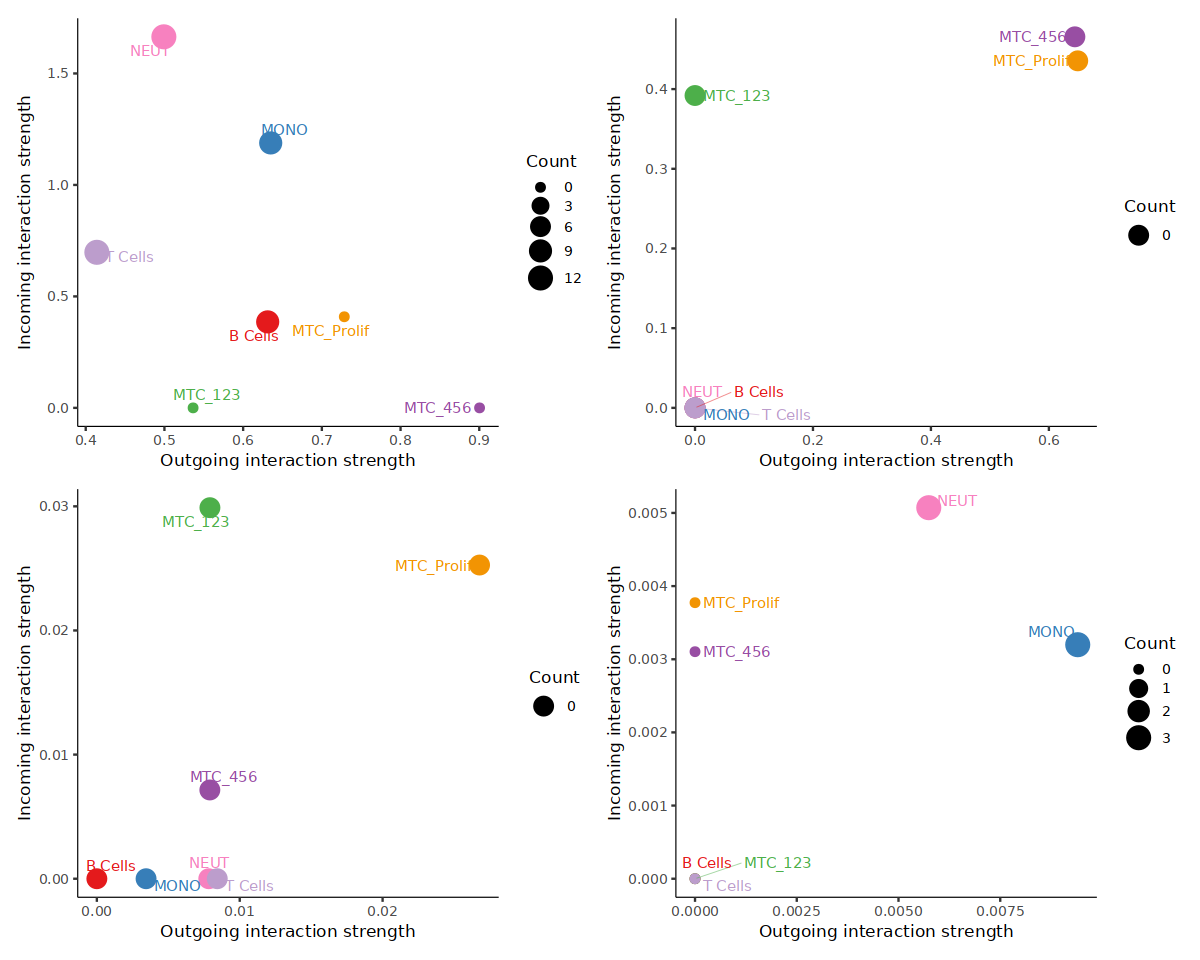

In [45]:
options(repr.plot.width=10, repr.plot.height=8)
netAnalysis_signalingRole_scatter(cellchat, signaling = c("SPP1"))+
netAnalysis_signalingRole_scatter(cellchat, signaling = c("ApoE"))+
netAnalysis_signalingRole_scatter(cellchat, signaling = c("TGFb"))+
netAnalysis_signalingRole_scatter(cellchat, signaling = c("IL10"))

Signaling role analysis on the cell-cell communication network from user's input



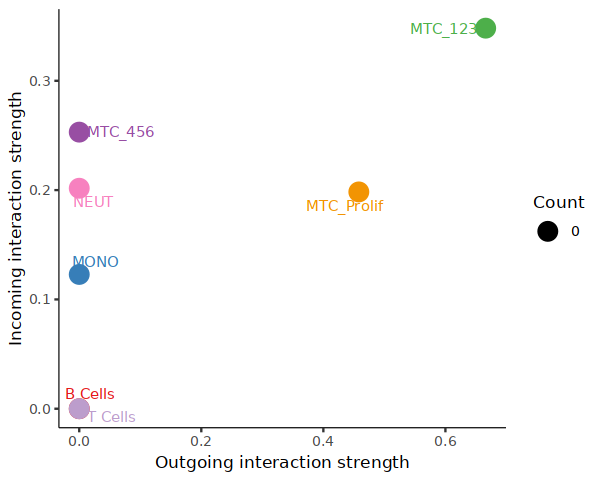

In [46]:
options(repr.plot.width=5, repr.plot.height=4)
netAnalysis_signalingRole_scatter(cellchat, signaling = c("COMPLEMENT"))